In [110]:
import json
import numpy as np

# make all args just normal variables with their names and default values
tokenlvl_file_path = "C:\\Users\\Tommaso Derossi\\OneDrive\\Desktop\\SPAR\\SPAR\\math_rollouts\\deepseek_deepseek-r1-distill-qwen-14b"
tokenlvl_file_name = "rollout_analysis.json"
sentencelvl_file_path = "C:\\Users\\Tommaso Derossi\\OneDrive\\Desktop\\SPAR\\SPAR\\thought_anchors\\.cache\\math_rollouts_hf\\deepseek-r1-distill-qwen-14b\\temperature_0.6_top_p_0.95"
sentencelvl_file_name = "chunks_labeled.json"
importance_measure = "delta_acc"
base_sol_type = "correct"
problems_to_compare = ["330"]

tkn_to_snt_importance_measure = {
    "delta_acc": "counterfactual_importance_accuracy",
    # "kl_true": "counterfactual_importance_kl", # this when thought_anchors.analyze_rollouts_v2.py was run with --use_prob_true
    "kl_full": "counterfactual_importance_kl",
}

In [ ]:
# correct sentence offsets

from typing import List, Dict, Tuple

def split_solution_into_chunks(
    solution_text: str,
    *,
    min_chunk_len: int = 10,
    trim_chunk_edges: bool = True,
) -> List[Dict[str, object]]:
    """
    Split a solution into chunks and return each chunk with offsets in the ORIGINAL CoT.

    Args:
        solution_text: The full solution text (possibly containing <think>...</think>).
        min_chunk_len: If a chunk is shorter than this, it will be merged with a neighbor.
        trim_chunk_edges: If True, strip leading/trailing whitespace from each chunk by
                          shifting offsets (without changing the original text).

    Returns:
        List of dicts with:
          - "chunk": str               (text slice from the original CoT)
          - "start": int               (start offset in the original CoT)
          - "end": int                 (end offset in the original CoT; exclusive)
    """
    original = solution_text

    # ------------------------------------------------------------------
    # 1) Determine the exact subrange of the original text to split.
    #    We emulate your previous behavior (<think>... strip ...</think> strip)
    #    but we do it by adjusting absolute offsets into `original`.
    # ------------------------------------------------------------------
    start = 0
    end = len(original)

    think_open = original.find("<think>")
    if think_open != -1:
        start = think_open + len("<think>")

    think_close = original.find("</think>", start)
    if think_close != -1:
        end = think_close

    # emulate the .strip() that was applied after extracting the think-block
    sub = original[start:end]
    # left trim
    ltrim = len(sub) - len(sub.lstrip())
    # right trim
    rtrim = len(sub) - len(sub.rstrip())
    start += ltrim
    end -= rtrim

    # If after trimming there's nothing to split, return empty
    if start >= end:
        return []

    # We'll scan within [start:end) of the ORIGINAL string, but all indices we
    # compute are absolute offsets into `original`.
    sentence_ending_tokens = {".", "?", "!"}
    paragraph_ending_patterns = ["\n\n", "\r\n\r\n"]

    spans: List[Tuple[int, int]] = []
    chunk_start = start
    i = start

    # ------------------------------------------------------------------
    # 2) Scan once and create chunk spans using your rules.
    # ------------------------------------------------------------------
    while i < end:
        boundary_end = None  # if this becomes an int, we cut a chunk at that position

        # Check paragraph endings first (multi-char)
        for pat in paragraph_ending_patterns:
            pat_len = len(pat)
            if i + pat_len <= end and original[i:i + pat_len] == pat:
                boundary_end = i + pat_len
                break

        # Otherwise, check sentence ending ('.', '?', '!') followed by space or newline
        if boundary_end is None:
            ch = original[i]
            if ch in sentence_ending_tokens and i + 1 < end:
                next_ch = original[i + 1]
                if next_ch == " " or next_ch == "\n":
                    boundary_end = i + 1  # include the punctuation in the chunk

        # If a boundary is found, close the chunk
        if boundary_end is not None:
            # Make a span only if there's something in it
            if boundary_end > chunk_start:
                spans.append((chunk_start, boundary_end))
            chunk_start = boundary_end
            i = boundary_end
        else:
            i += 1

    # Add the trailing span (if any)
    if chunk_start < end:
        spans.append((chunk_start, end))

    # ------------------------------------------------------------------
    # 3) Optionally trim chunk edges by shifting offsets (NOT changing text).
    # ------------------------------------------------------------------
    if trim_chunk_edges:
        trimmed_spans = []
        for s, e in spans:
            # Left trim
            while s < e and original[s].isspace():
                s += 1
            # Right trim
            while e > s and original[e - 1].isspace():
                e -= 1
            if s < e:
                trimmed_spans.append((s, e))
        spans = trimmed_spans

    # ------------------------------------------------------------------
    # 4) Merge small chunks (< min_chunk_len) by merging spans (no extra characters).
    #    We merge with the next chunk when possible; otherwise with the previous.
    # ------------------------------------------------------------------
    merged: List[Tuple[int, int]] = []
    i = 0
    while i < len(spans):
        s, e = spans[i]
        if (e - s) < min_chunk_len:
            if i < len(spans) - 1:
                # Merge into the next span
                ns, ne = spans[i + 1]
                s2, e2 = s, ne  # expanded span
                spans[i + 1] = (s2, e2)
                i += 1  # skip current; the next now holds the merged span
                continue
            elif merged:
                # Merge into the previous span
                ps, pe = merged[-1]
                merged[-1] = (ps, e)
            else:
                # Single tiny span; keep as-is
                merged.append((s, e))
        else:
            merged.append((s, e))
        i += 1

    spans = merged

    # ------------------------------------------------------------------
    # 5) Build results with absolute offsets and original slices.
    # ------------------------------------------------------------------
    results = [
        {"chunk": original[s:e], "start": s, "end": e}
        for (s, e) in spans
    ]
    return results



0 (0, 62) "Okay, so I've got this math problem here that I need to solve."
1 (63, 172) "It looks a bit complicated at first glance, but maybe if I break it down step by step, it'll make more sense."
2 (173, 188) 'The problem is:'
3 (190, 247) 'Compute\n\n$3(1+3(1+3(1+3(1+3(1+3(1+3(1+3(1+3(1+3)))))))))$'
4 (249, 293) "Wow, that's a lot of parentheses and threes."
5 (294, 330) 'Let me see if I can figure this out.'
6 (332, 454) 'First, I notice that the expression is a nested set of terms where each term is 1 plus 3 times another similar expression.'
7 (455, 590) "It seems like there's a repeating pattern here, which might mean that I can solve it by working from the innermost parentheses outward."
8 (591, 713) 'That makes sense because each opening parenthesis must be closed eventually, so starting from the inside would be logical.'
9 (715, 777) 'Let me write down the expression again to visualize it better:'
10 (779, 843) '3(1 + 3(1 + 3(1 + 3(1 + 3(1 + 3(1 + 3(1 + 3(1 + 3(1 + 3))))))))

In [136]:
for problem in problems_to_compare:
    tkn_lvl_file_w_path = (
        tokenlvl_file_path
        + f"\problem_{problem}\samples_30_topk_10_prob_0.05\{tokenlvl_file_name}"
    )

    snt_lvl_file_w_path = f"{sentencelvl_file_path}\{base_sol_type}_base_solution\problem_{problem}\{sentencelvl_file_name}"

    with open(snt_lvl_file_w_path, "r", encoding="utf-8") as f:
        sent_data = json.load(f)

    with open(tkn_lvl_file_w_path, "r", encoding="utf-8") as f:
        token_data = json.load(f)
        
    snt_lvl_base_file_w_path = f"{sentencelvl_file_path}\{base_sol_type}_base_solution\problem_{problem}\\base_solution.json"

    with open(snt_lvl_base_file_w_path, "r", encoding="utf-8") as f:
        sent_data_base = json.load(f)
        
    cot_text = sent_data_base["solution"]

    # Further processing and comparison logic goes here
    tok_importance_offsets = []
    for tok in token_data["token_steps"]:
        tok_importance_offsets.append(
            (
                tok["token"],
                tok["cf_metrics"][importance_measure]
                if "cf_metrics" in tok
                else 0,
                tok["text_offset"],
                tok["text_offset"] + len(tok["token"]),
            )
        )    
    
    correct_offsets_in_original_cot = split_solution_into_chunks(cot_text) # corrected sentence offsets
    
    sent_importance_offsets = []
    chunk_id = 0
    for chunk in sent_data:
        sent_importance_offsets.append(
            (
                chunk["chunk"],
                chunk[tkn_to_snt_importance_measure[importance_measure]],
                correct_offsets_in_original_cot[chunk_id]["start"],
                correct_offsets_in_original_cot[chunk_id]["end"],
            )
        )
        chunk_id += 1

    # 1
    # now for every sentence we compute the total/max/avg importance of the tokens that at least partially fall within its offsets
    sent_token_importance = []
    for sent, sent_imp, sent_start, sent_end in sent_importance_offsets:
        overlapping_token_importances = []
        for tok, tok_imp, tok_start, tok_end in tok_importance_offsets:
            # check for overlap
            if not (tok_end <= sent_start or tok_start >= sent_end):
                overlapping_token_importances.append(tok_imp)
        if overlapping_token_importances:
            avg_imp = sum(overlapping_token_importances) / len(
                overlapping_token_importances
            )
            # max can be positive or negative, the value to insert should be the one with the highest absolute value
            max_imp = max(overlapping_token_importances, key=abs)
            total_imp = sum(overlapping_token_importances)
        else:
            avg_imp = 0
            max_imp = 0
            total_imp = 0
        sent_token_importance.append((sent, sent_imp, avg_imp, max_imp, total_imp))

    # now we want to compute correlation metrics between sent_imp and avg_imp/max_imp/total_imp and the rank correlation between the sentence importance and the token importance rankings
    import scipy.stats as stats

    sent_importances = [x[1] for x in sent_token_importance]
    avg_token_importances = [x[2] for x in sent_token_importance]
    max_token_importances = [x[3] for x in sent_token_importance]
    total_token_importances = [x[4] for x in sent_token_importance]
    pearson_avg = stats.pearsonr(sent_importances, avg_token_importances)
    spearman_avg = stats.spearmanr(sent_importances, avg_token_importances)
    pearson_max = stats.pearsonr(sent_importances, max_token_importances)
    spearman_max = stats.spearmanr(sent_importances, max_token_importances)
    pearson_total = stats.pearsonr(sent_importances, total_token_importances)
    spearman_total = stats.spearmanr(sent_importances, total_token_importances)

<string>:4: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<>:4: SyntaxWarning: invalid escape sequence '\{'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\{'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<string>:4: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<>:4: SyntaxWarning: invalid escape sequence '\{'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\s

In [137]:
# get token, token importance and token offsets of a given token index
def get_token_info(index):
    if 0 <= index < len(tok_importance_offsets):
        token, importance, start, end = tok_importance_offsets[index]
        return token, importance, start, end
    else:
        return None, None, None, None
# Example usage:
index = 10  # replace with desired index
token, importance, start, end = get_token_info(2460)
print(f"Token: {token}, Importance: {importance}, Start: {start}, End: {end}")

Token: 5, Importance: -1.0, Start: 5946, End: 5947


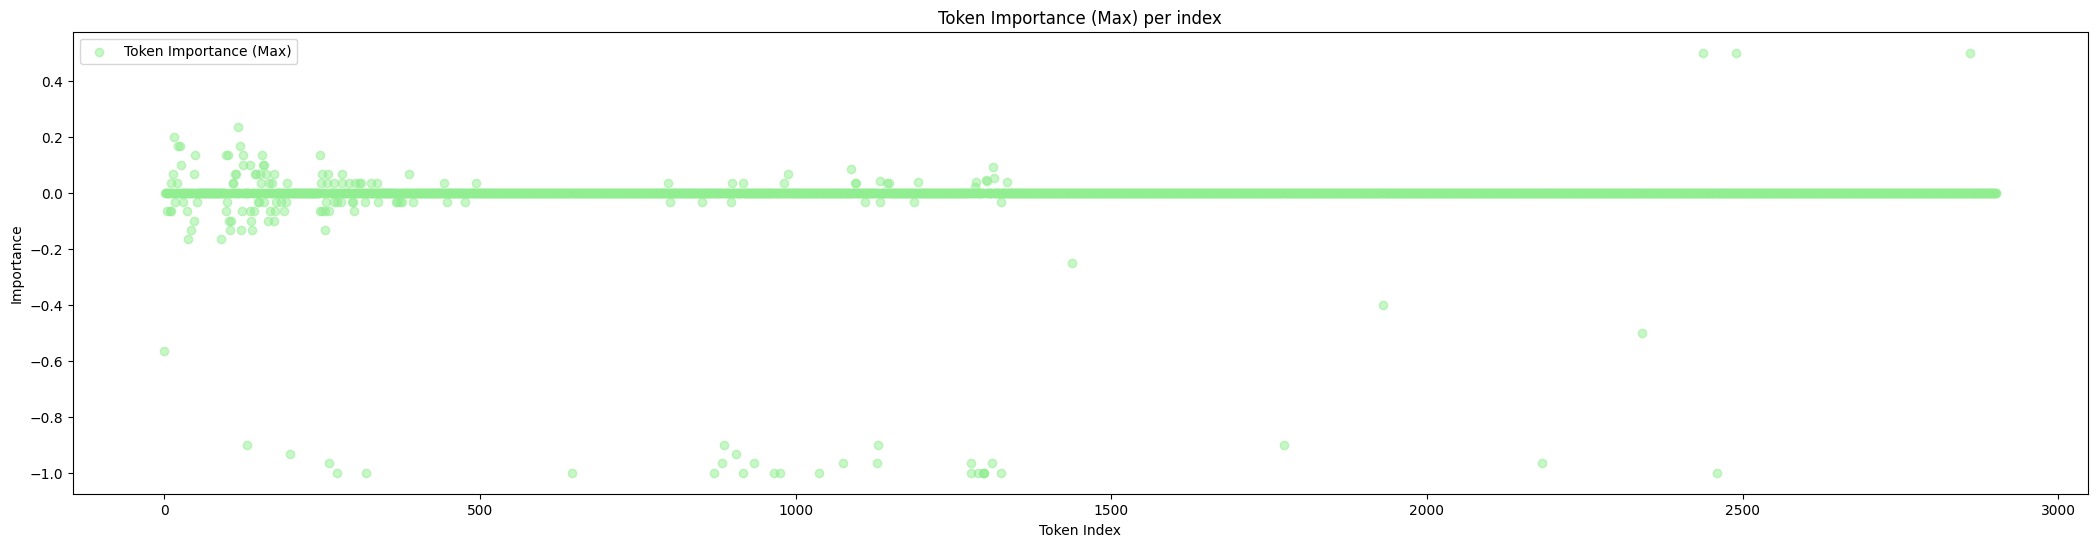

In [138]:
# PLOTTING
import matplotlib.pyplot as plt

# PLOT 1 (token importance scatter plots)
plt.figure(figsize=(26, 6))
plt.scatter(
    range(len(tok_importance_offsets)),
    [tok_importance_offsets[i][1] for i in range(len(tok_importance_offsets))],
    color="lightgreen",
    label="Token Importance (Max)",
    alpha=0.5,
)
plt.xlabel("Token Index")
plt.ylabel("Importance")
plt.title("Token Importance (Max) per index")
plt.legend()
plt.show()


In [139]:
# extract token indices that have an importance  lower than -20
min_importance = 0

high_importance_tokens = [
    i for i, (tok, imp, _, _) in enumerate(tok_importance_offsets) if np.abs(imp) > min_importance
]
print(f"Found {len(high_importance_tokens)} tokens with importance greater than {min_importance}")
print(f"Tokens with high importance, greater than {min_importance}:")
for i in high_importance_tokens:
    print(f"Index: {i}, Token: {tok_importance_offsets[i][0]}, Importance: {tok_importance_offsets[i][1]}")
   

Found 165 tokens with importance greater than 0
Tokens with high importance, greater than 0:
Index: 0, Token: Okay, Importance: -0.5666666666666667
Index: 4, Token:  have, Importance: -0.06666666666666665
Index: 9, Token:  here, Importance: -0.06666666666666665
Index: 10, Token:  that, Importance: 0.033333333333333326
Index: 11, Token:  I, Importance: -0.06666666666666665
Index: 14, Token:  compute, Importance: 0.06666666666666665
Index: 15, Token: ., Importance: 0.19999999999999996
Index: 17, Token:  looks, Importance: -0.033333333333333326
Index: 20, Token:  intimidating, Importance: 0.033333333333333326
Index: 21, Token:  at, Importance: 0.16666666666666663
Index: 24, Token: ,, Importance: 0.16666666666666674
Index: 26, Token:  maybe, Importance: 0.09999999999999998
Index: 29, Token:  break, Importance: -0.033333333333333326
Index: 36, Token:  it, Importance: -0.06666666666666665
Index: 37, Token: 'll, Importance: -0.16666666666666663
Index: 42, Token:  The, Importance: -0.133333333

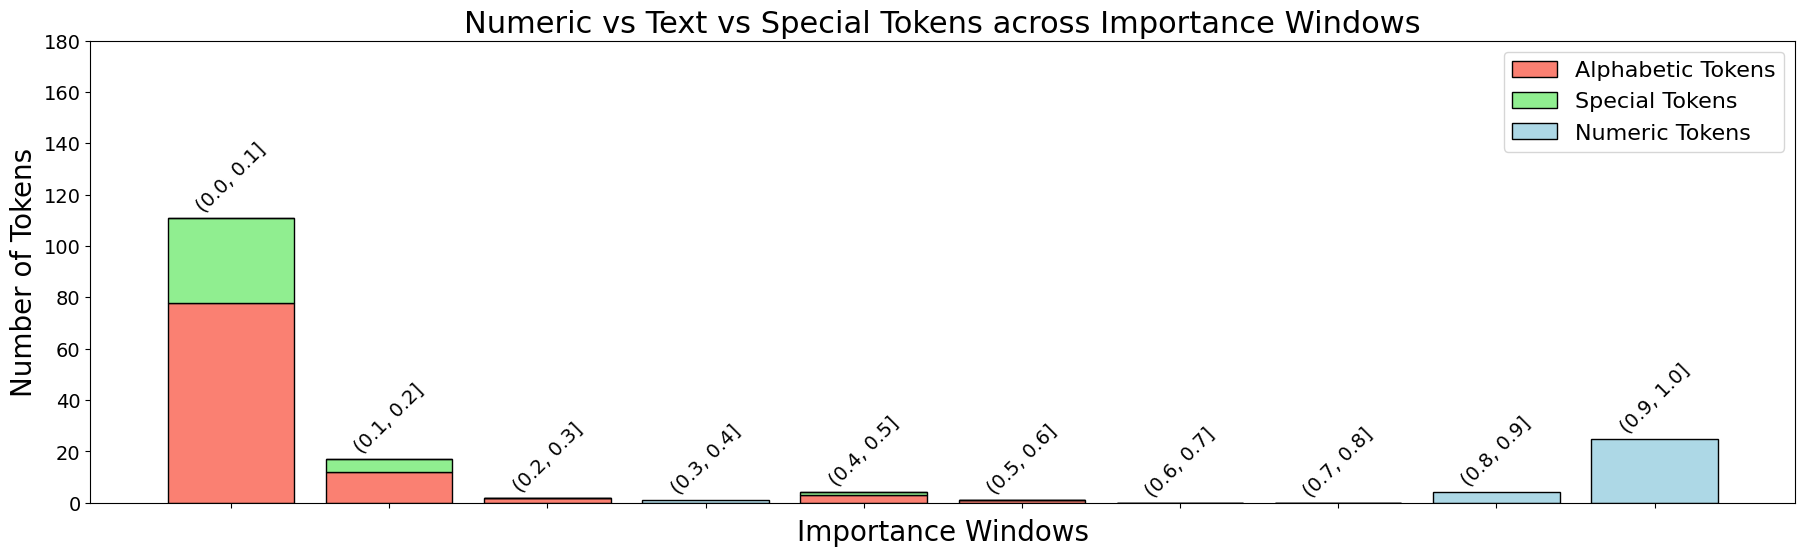

In [140]:
 

# PLOT 2 (numeric tokens vs text vs special characters at various importance windows, histogram with bars of 3 colors (different colors for numeric, non-numeric and special tokens))

"""
# one bar per importance window splitted in two parts (numeric and non-numeric) of different colors
importance_windows = [0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]#, 100.0]
# make importance windows equally spaced

numeric_counts = []
text_counts = []
special_counts = []
for i in range(len(importance_windows) - 1):
    lower = importance_windows[i]
    upper = importance_windows[i + 1]
    numeric_count = 0
    text_count = 0
    special_count = 0
    for tok, imp, _, _ in tok_importance_offsets:
        if lower < np.abs(imp) <= upper:
            try:
                int(tok)
                numeric_count += 1
                #print(f"Numeric token found: {tok} with importance {imp}")
            except:
                if any(char in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ" for char in tok):
                    text_count += 1
                    #print(f"Alphabetic token found: {tok} with importance {imp}")
                else:
                    special_count += 1
                    #print(f"Special token found: {tok} with importance {imp}")
    numeric_counts.append(numeric_count)
    text_counts.append(text_count)
    special_counts.append(special_count)
# plot bars
x = np.arange(len(importance_windows) - 1)

plt.figure(figsize=(22, 6))
# one single bar per importance window vertically splitted in two parts (numeric part red and non-numeric part blue)
plt.bar(x, text_counts, label="Alphabetic Tokens", color="salmon", edgecolor='black')
plt.bar(x, special_counts, label="Special Tokens", color="lightgreen", bottom=text_counts, edgecolor='black')
plt.bar(x, numeric_counts, label="Numeric Tokens", color="lightblue", bottom=np.array(special_counts) + np.array(text_counts), edgecolor='black')

plt.xticks(x, [f"({importance_windows[i]}, {importance_windows[i+1]}]" for i in range(len(importance_windows) - 1)])
plt.xlabel("Importance Windows", fontsize=20)
plt.ylabel("Number of Tokens", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# I want to set the size only of the y axis
plt.ylim(0,40)
plt.title("Numeric vs Text vs Special Tokens across Importance Windows", fontsize=22)
plt.legend(fontsize=16)
plt.show()
"""
importance_windows_equally_spaced = np.linspace(0,1,11)

numeric_counts = []
text_counts = []
special_counts = []
for i in range(len(importance_windows_equally_spaced) - 1):
    lower = importance_windows_equally_spaced[i]
    upper = importance_windows_equally_spaced[i + 1]
    numeric_count = 0
    text_count = 0
    special_count = 0
    for tok, imp, _, _ in tok_importance_offsets:
        if lower < np.abs(imp) <= upper:
            try:
                int(tok)
                numeric_count += 1
                #print(f"Numeric token found: {tok} with importance {imp}")
            except:
                if any(char in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ" for char in tok):
                    text_count += 1
                    #print(f"Alphabetic token found: {tok} with importance {imp}")
                else:
                    special_count += 1
                    #print(f"Special token found: {tok} with importance {imp}")
    numeric_counts.append(numeric_count)
    text_counts.append(text_count)
    special_counts.append(special_count)

x = np.arange(len(importance_windows_equally_spaced) - 1)
fig, ax = plt.subplots(figsize=(22, 6))

bars1 = ax.bar(x, text_counts, label="Alphabetic Tokens", color="salmon", edgecolor='black')
bars2 = ax.bar(x, special_counts, label="Special Tokens", color="lightgreen", bottom=text_counts, edgecolor='black')
bars3 = ax.bar(x, numeric_counts, label="Numeric Tokens", color="lightblue", bottom=np.array(special_counts) + np.array(text_counts), edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels([f"({np.round(importance_windows_equally_spaced[i], 1)}, {np.round(importance_windows_equally_spaced[i+1], 1)}]" for i in range(len(importance_windows_equally_spaced) - 1)], fontsize=14)
ax.set_xlabel("Importance Windows", fontsize=20)
ax.set_ylabel("Number of Tokens", fontsize=20)
ax.set_ylim(0, 180)
ax.set_title("Numeric vs Text vs Special Tokens across Importance Windows", fontsize=22)
ax.legend(fontsize=16)
ax.tick_params(axis='y', labelsize=14)
# 👉 Annotate the tick labels at the top of each bar
total_counts = np.array(text_counts) + np.array(special_counts) + np.array(numeric_counts)
for i, (label, height) in enumerate(zip(ax.get_xticklabels(), total_counts)):
    ax.text(i, height + 1, label.get_text(), ha='center', va='bottom', fontsize=14, rotation=45)

# Optionally remove the bottom tick labels to avoid duplication
ax.set_xticklabels([])
plt.show()

Threshold for top 90th percentile: 0.0


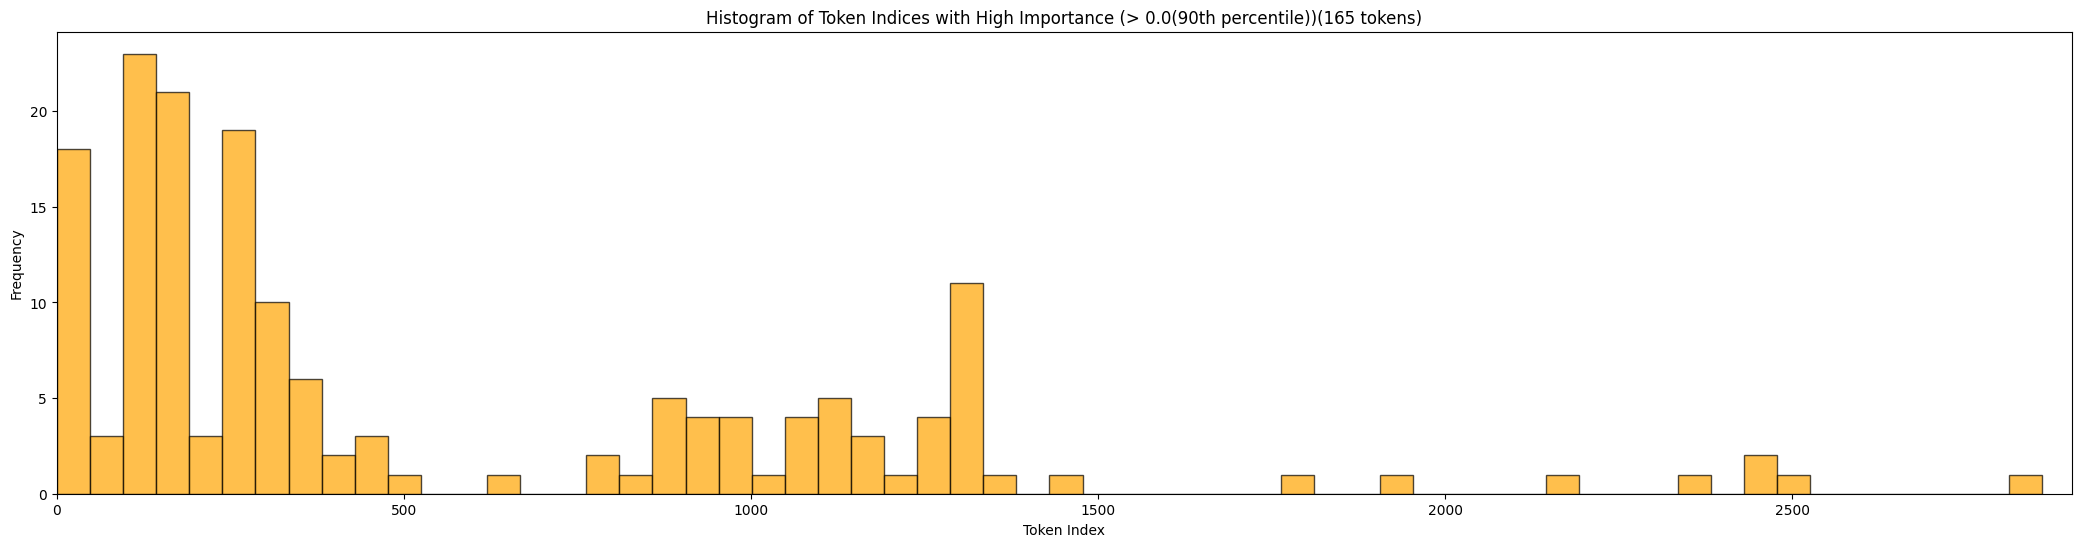

In [141]:
# PLOT 2 (histogram of most important tokens indices)

# the threshold is set as the 80th percentile of absolute importance values
percentile = 90
threshold = np.percentile(
    [np.abs(tok_importance_offsets[i][1]) for i in range(len(tok_importance_offsets))],
    percentile,
)
print(f"Threshold for top {percentile}th percentile: {threshold}")
# take all non-zero importance tokens
threshold = 0.0


plt.figure(figsize=(26, 6))
# hist with the x axis covering all the range of token indices, but only counting those with importance > threshold
plt.hist(
    [i for i in range(len(tok_importance_offsets)) if np.abs(tok_importance_offsets[i][1]) > threshold],
    bins=60,
    color="orange",
    alpha=0.7,
    edgecolor="black",
)
plt.xlim(0, len(tok_importance_offsets))
plt.xlabel("Token Index")
plt.ylabel("Frequency")
# ensure that threshold digits are shown properly
plt.title(f"Histogram of Token Indices with High Importance (> {threshold}({percentile}th percentile))({len([i for i in range(len(tok_importance_offsets)) if np.abs(tok_importance_offsets[i][1]) > threshold])} tokens)")
plt.show()

Top 139 tokens with highest importance: [('3', -1.0, 943, 944), ('1', -1.0, 1155, 1156), ('0', -1.0, 1877, 1878), ('2', -1.0, 2353, 2354), ('3', -1.0, 2415, 2416), ('2', -1.0, 2533, 2534), ('4', -1.0, 2545, 2546), ('9', -1.0, 2687, 2688), ('5', -1.0, 3233, 3234), ('2', -1.0, 3261, 3262), ('2', -1.0, 3273, 3274), ('0', -1.0, 3274, 3275), ('5', -1.0, 3275, 3276), ('2', -1.0, 3328, 3329), ('5', -1.0, 5946, 5947), ('1', -0.9666666666666667, 903, 904), ('3', -0.9666666666666667, 2372, 2373), ('4', -0.9666666666666667, 2436, 2437), ('2', -0.9666666666666667, 2762, 2763), ('9', -0.9666666666666667, 2883, 2884), ('8', -0.9666666666666667, 3232, 3233), ('4', -0.9666666666666667, 3301, 3302), ('9', -0.9666666666666667, 5207, 5208), ('3', -0.9333333333333333, 779, 780), ('0', -0.9333333333333333, 2402, 2403), ('1', -0.9, 412, 413), ('0', -0.9, 2377, 2378), ('5', -0.9, 2884, 2885), ('4', -0.9, 4269, 4270), ('Okay', -0.5666666666666667, 0, 4), ('\n\n', -0.5, 5425, 5427), (' careful', 0.5, 5836, 584

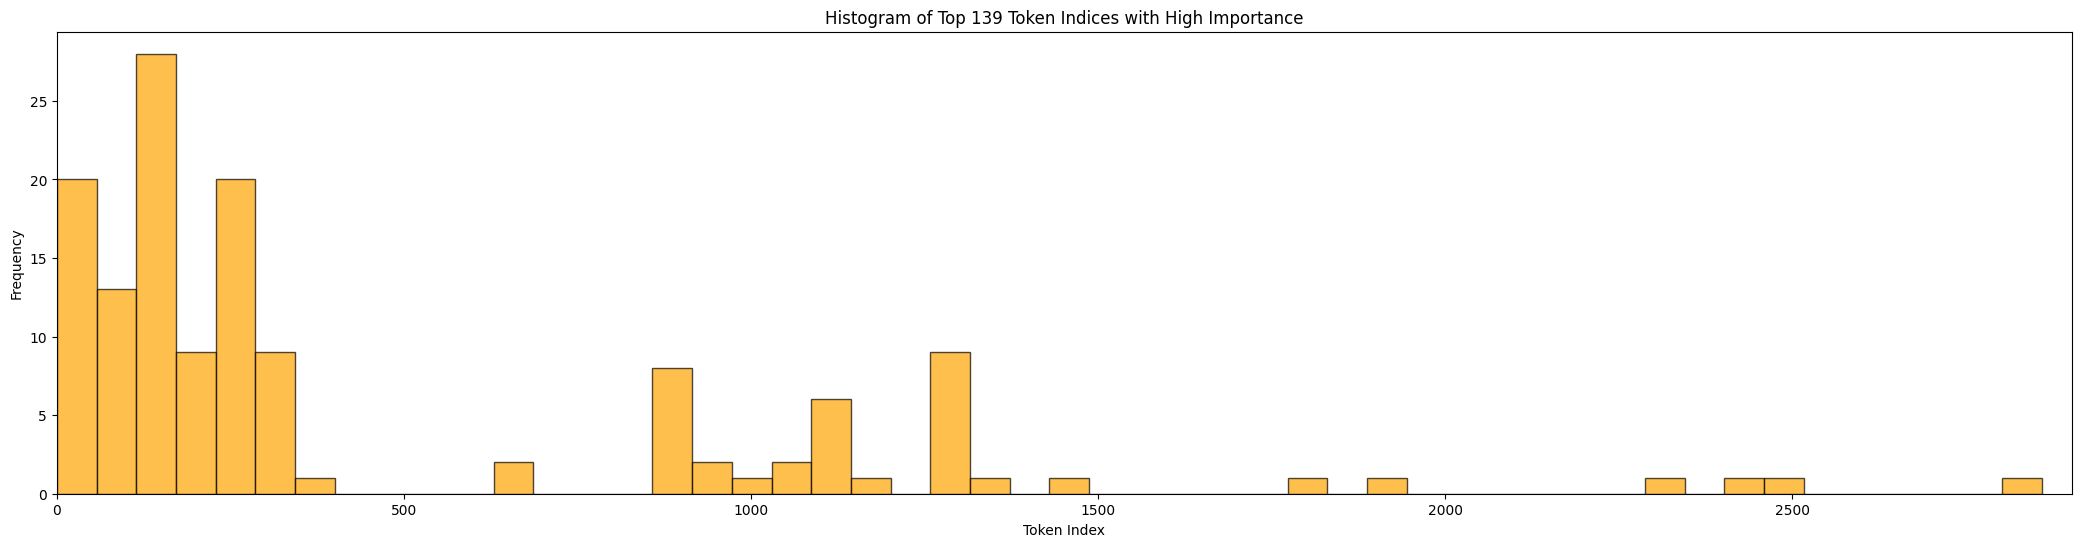

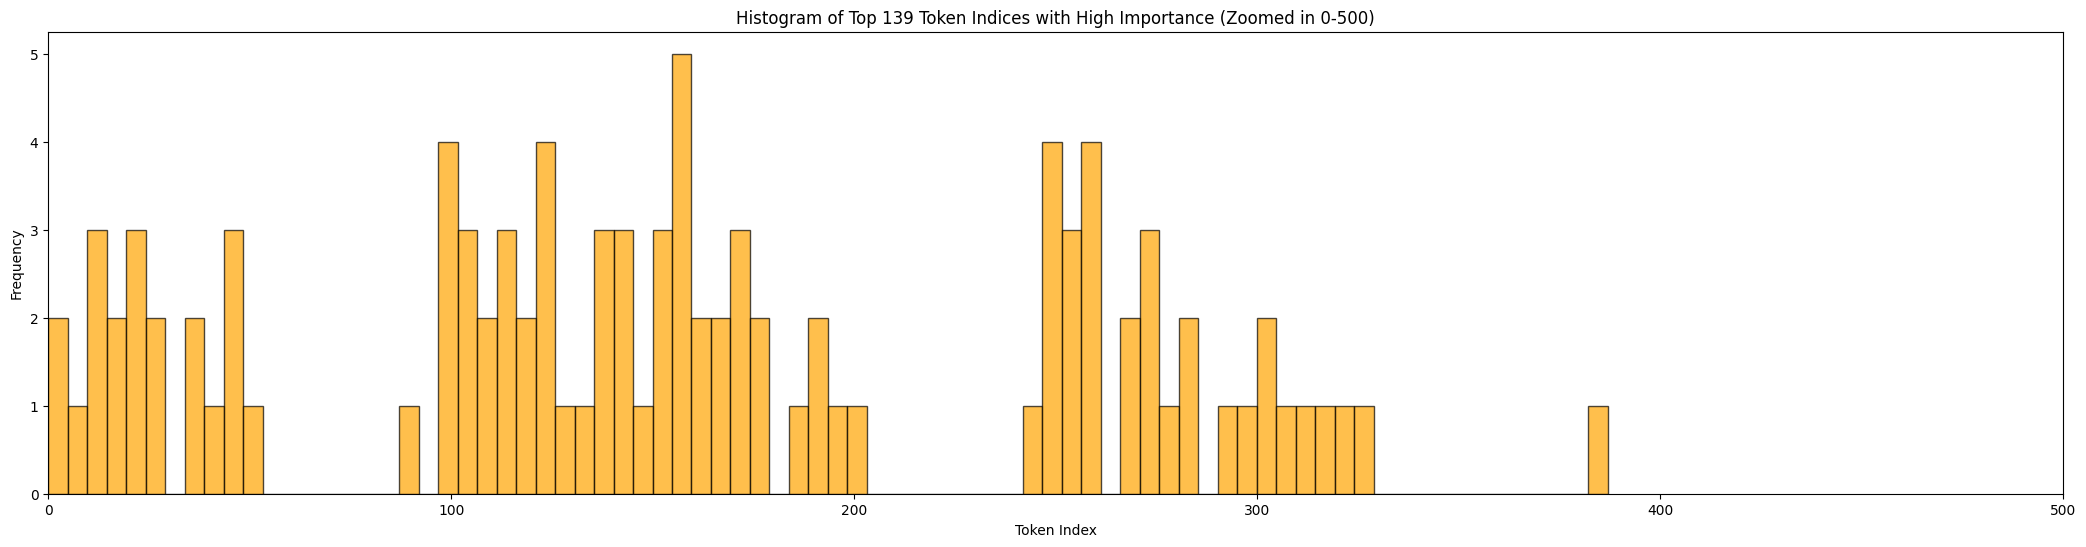

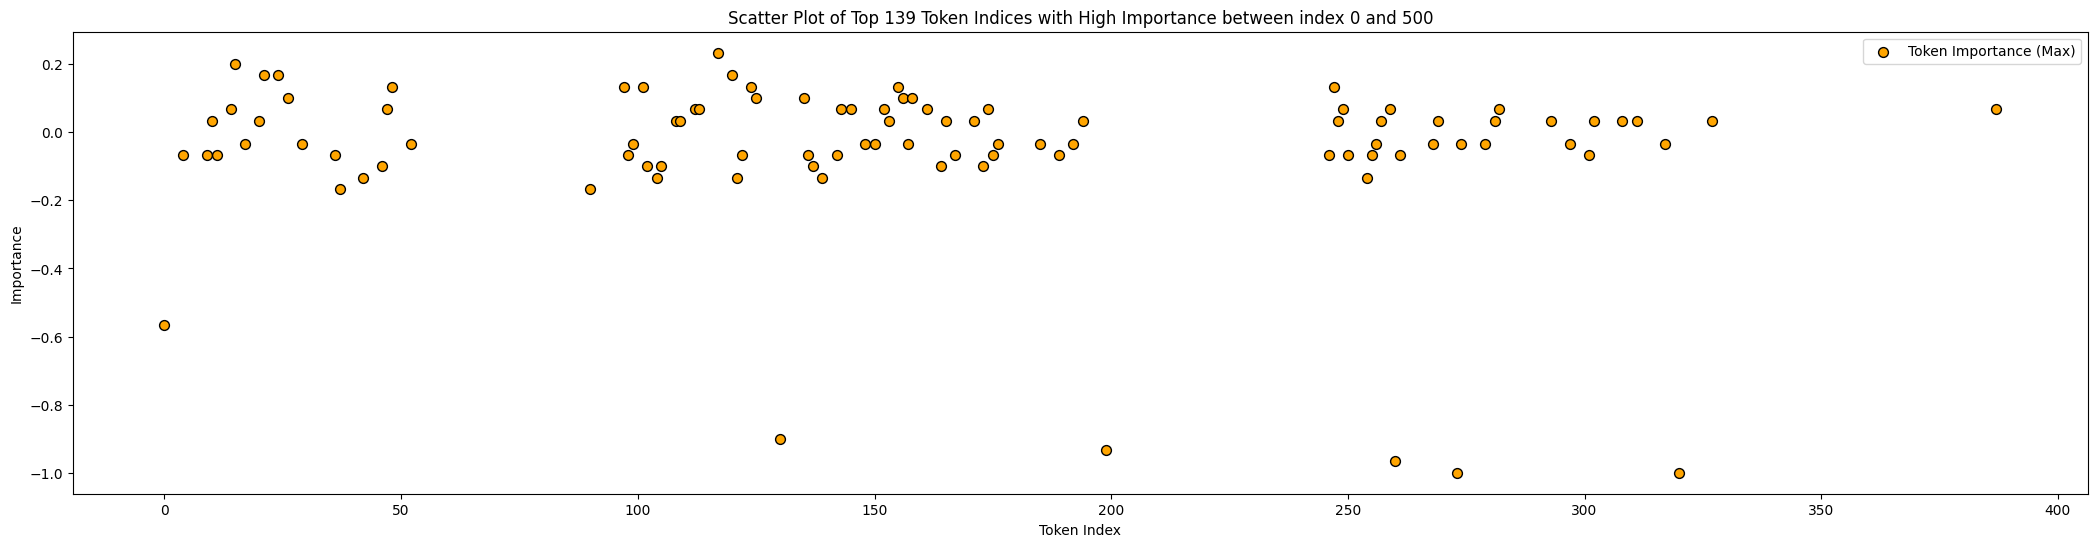

In [142]:
# PLOT 2 (histogram of k( = number of sentences) most important tokens indices)

k = len(sent_importance_offsets)  # number of most important tokens to consider
top_k_tokens = sorted(tok_importance_offsets, key=lambda x: np.abs(x[1]), reverse=True)[:k]
print(f"Top {k} tokens with highest importance: {top_k_tokens}")
# the following top_k_indices is empty if there are duplicate importance values, so we need to get the indices differently
top_k_indices = []
for tok, imp, _, _ in top_k_tokens:
    for i, (t, im, _, _) in enumerate(tok_importance_offsets):
        if t == tok and im == imp:
            top_k_indices.append(i)
            break
print(f"Indices of top {k} tokens: {top_k_indices}")
plt.figure(figsize=(26, 6))
plt.hist(
    top_k_indices,
    bins=50,
    color="orange",
    alpha=0.7,
    edgecolor="black",
)
plt.xlim(0, len(tok_importance_offsets))
plt.xlabel("Token Index")
plt.ylabel("Frequency")
plt.title(f"Histogram of Top {k} Token Indices with High Importance")
plt.show()

# zoom in the first plot to show only most important tokens indices with indices between 0 and 500
plt.figure(figsize=(26, 6))
plt.hist(
    [i for i in top_k_indices if i < 500],
    bins=80,
    color="orange",
    alpha=0.7,
    edgecolor="black",
)
plt.xlim(0, 500)
plt.xlabel("Token Index")
plt.ylabel("Frequency")
plt.title(f"Histogram of Top {k} Token Indices with High Importance (Zoomed in 0-500)")
plt.show()

# now a scatter from min index to max index having the y values equal to the importance of that token (only for the top k important tokens)
min_index = 0
max_index = 500
plt.figure(figsize=(26, 6))
# in the scatter, only plot those tokens that are in top_k_indices, the rest should be ignored but the x axis should cover all tokens from min_index to max_index
# I want the points to be vertical lines
plt.scatter(
    [i for i in range(min_index, max_index) if i in top_k_indices],
    [tok_importance_offsets[i][1] for i in range(min_index, max_index) if i in top_k_indices],
    color="orange",
    label="Token Importance (Max)",
    alpha=1,
    #linewidth=1,
    #marker="|",
    edgecolor="black",
    s=50
)
plt.xlabel("Token Index")
plt.ylabel("Importance")
plt.title(f"Scatter Plot of Top {k} Token Indices with High Importance between index {min_index} and {max_index}")
plt.legend()
plt.show()



In [143]:
# how many tokens with non zero importance are not adjacent to another token with non zero importance?
min_importance = 0
high_importance_tokens = [
    i for i, (tok, imp, _, _) in enumerate(tok_importance_offsets) if np.abs(imp) > min_importance
]

non_adjacent_count = 0
for i in high_importance_tokens:
    if (i - 1 not in high_importance_tokens) and (i + 1 not in high_importance_tokens):
        non_adjacent_count += 1
print(f"Found {non_adjacent_count} tokens with importance greater than {min_importance} that are not adjacent to another token with importance greater than {min_importance}")
print(f"Percentage: {non_adjacent_count / len(high_importance_tokens) * 100:.2f}%")

Found 77 tokens with importance greater than 0 that are not adjacent to another token with importance greater than 0
Percentage: 46.67%


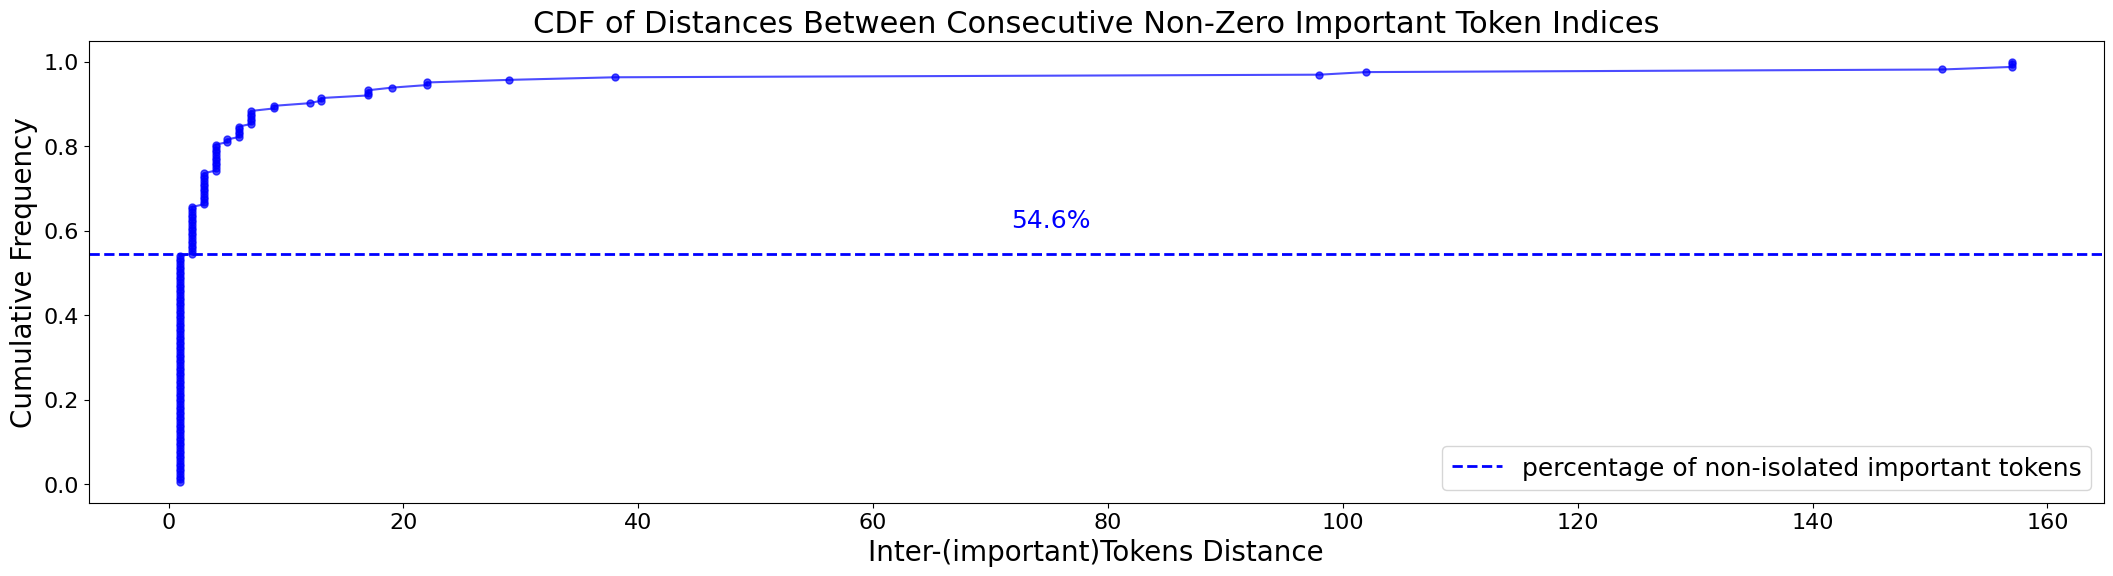

In [144]:
# now I want to plot the non-zero importance tokens inter-distances (between their indices) as a histogram
important_token_indices = [
    i for i, (tok, imp, _, _) in enumerate(tok_importance_offsets) if np.abs(imp) > min_importance
]

important_token_indices = sorted(important_token_indices)
distances = [
    min(important_token_indices[i] - important_token_indices[i - 1], important_token_indices[i + 1] - important_token_indices[i])
    for i in range(1, len(important_token_indices) - 1)
]
"""
plt.figure(figsize=(26, 6))
plt.hist(
    distances,
    bins=140,
    color="purple",
    alpha=0.7,
    edgecolor="black",
)
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title(f"Histogram of Distances Between Top {k} Important Consecutive Token Indices")
plt.show()
"""

# plot the cumulative distribution function (CDF) of the distances between the k most important tokens (0 to max distance in the x axis, frequency normalized to 1 in the y axis)
sorted_distances = np.sort(distances)
plt.figure(figsize=(26, 6))
# plot a line plot of the CDF not a histogram
cum_freq = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
non_zero_cum_freq_index = np.where(sorted_distances > 1)[0][0]

plt.plot(
    sorted_distances,
    cum_freq,
    color="blue",
    alpha=0.7,
    marker="o",
    markersize=5,
    linestyle='-',
)
# draw an horizontal line at at the y where x > 1
plt.axhline(y=cum_freq[non_zero_cum_freq_index], color='blue', linestyle='--', linewidth=2, label='percentage of non-isolated important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=sorted_distances[-1] * 0.5,  # position near the right side of the plot
    y=cum_freq[non_zero_cum_freq_index] + 0.05,               # a little above the line
    s=f"{cum_freq[non_zero_cum_freq_index]*100:.1f}%",         # formatted text
    color='blue',
    fontsize=18,
    ha='right',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)
plt.xlabel("Inter-(important)Tokens Distance", fontsize=20)
plt.ylabel("Cumulative Frequency", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title(f"CDF of Distances Between Consecutive Non-Zero Important Token Indices", fontsize=22)
plt.legend(fontsize=18)
plt.show()


# now

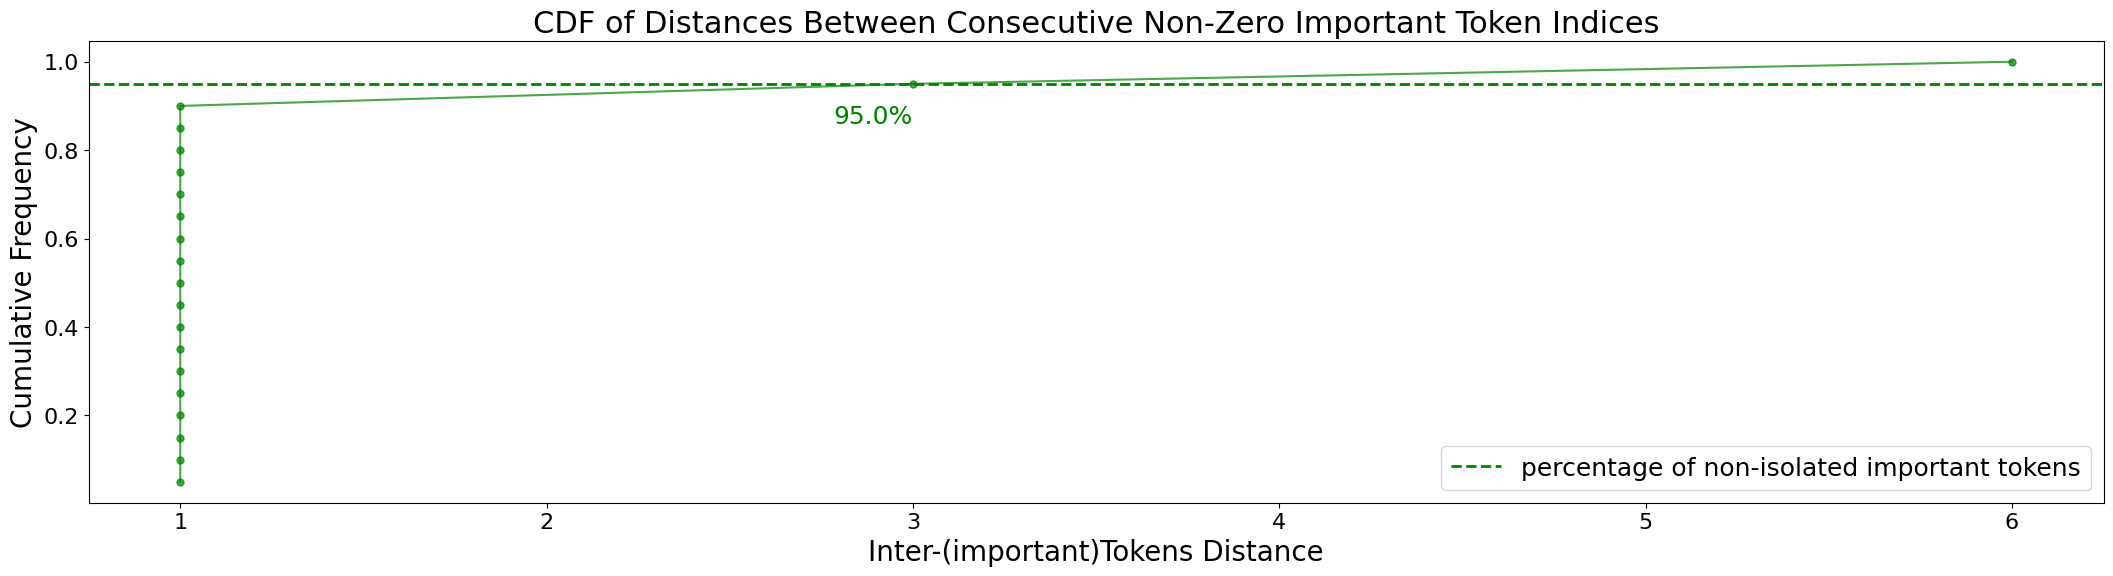

In [145]:
# now I want to plot the non-zero importance sentences inter-distances (between their indices) as a histogram
important_sentence_indices = [
    i for i, (sent, imp, _, _) in enumerate(sent_importance_offsets) if np.abs(imp) > min_importance
]

important_sentence_indices = sorted(important_sentence_indices)
distances = [
    min(important_sentence_indices[i] - important_sentence_indices[i - 1], important_sentence_indices[i + 1] - important_sentence_indices[i])
    for i in range(1, len(important_sentence_indices) - 1)
]
"""
plt.figure(figsize=(26, 6))
plt.hist(
    distances,
    bins=140,
    color="purple",
    alpha=0.7,
    edgecolor="black",
)
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title(f"Histogram of Distances Between Top {k} Important Consecutive Token Indices")
plt.show()
"""

# plot the cumulative distribution function (CDF) of the distances between the k most important tokens (0 to max distance in the x axis, frequency normalized to 1 in the y axis)
sorted_distances = np.sort(distances)
plt.figure(figsize=(26, 6))
# plot a line plot of the CDF not a histogram
cum_freq = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
non_zero_cum_freq_index = np.where(sorted_distances > 1)[0][0]

plt.plot(
    sorted_distances,
    cum_freq,
    color="green",
    alpha=0.7,
    marker="o",
    markersize=5,
    linestyle='-',
)
# draw an horizontal line at at the y where x > 1
plt.axhline(y=cum_freq[non_zero_cum_freq_index], color='green', linestyle='--', linewidth=2, label='percentage of non-isolated important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=sorted_distances[-1] * 0.5,  # position near the right side of the plot
    y=cum_freq[non_zero_cum_freq_index] - 0.1,               # a little below the line
    s=f"{cum_freq[non_zero_cum_freq_index]*100:.1f}%",         # formatted text
    color='green',
    fontsize=18,
    ha='right',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)
plt.xlabel("Inter-(important)Tokens Distance", fontsize=20)
plt.ylabel("Cumulative Frequency", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title(f"CDF of Distances Between Consecutive Non-Zero Important Token Indices", fontsize=22)
plt.legend(fontsize=18)
plt.show()

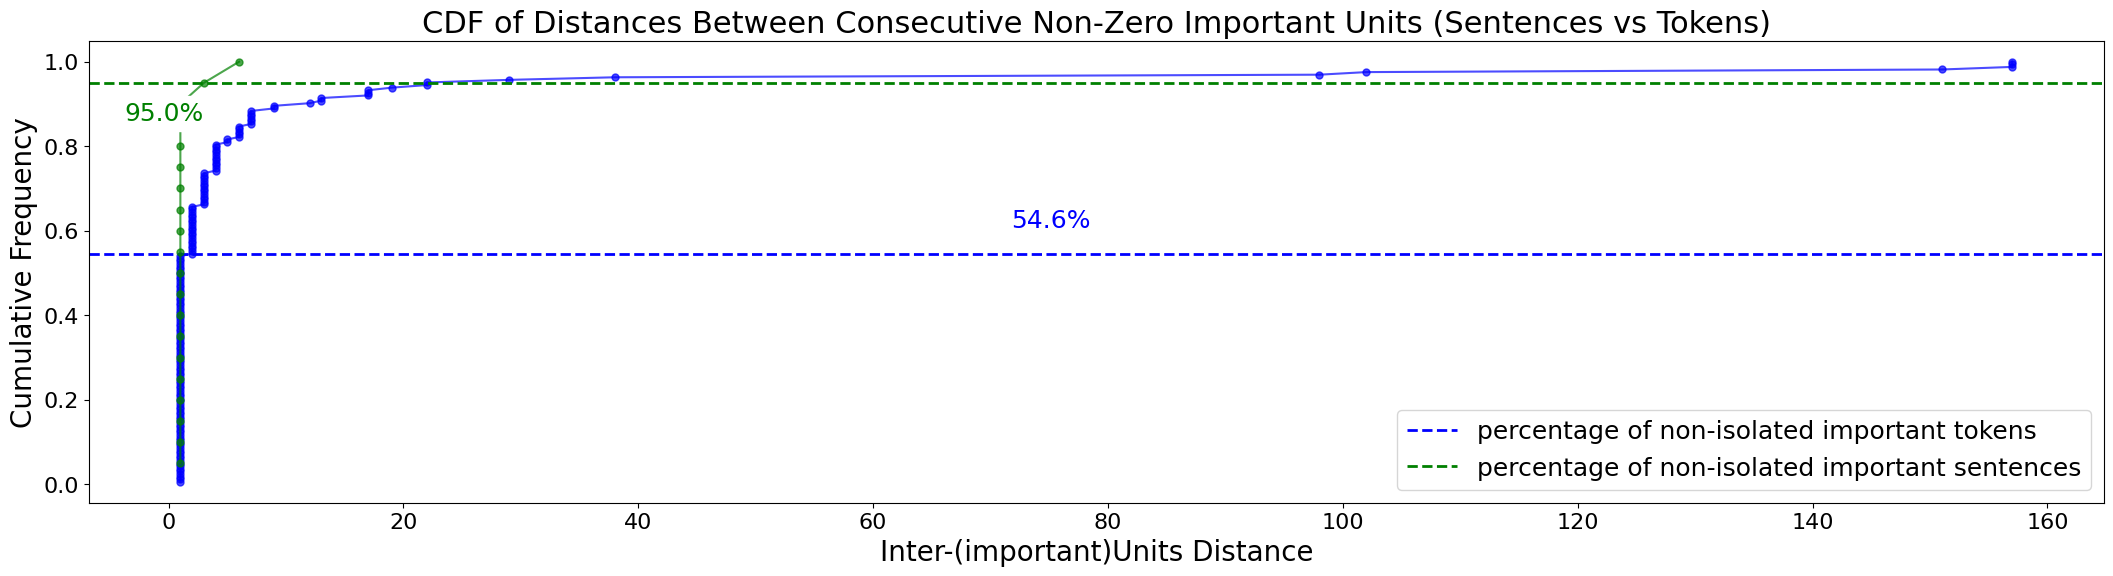

In [146]:
# comparison
important_token_indices = [
    i for i, (tok, imp, _, _) in enumerate(tok_importance_offsets) if np.abs(imp) > min_importance
]

important_token_indices = sorted(important_token_indices)
token_distances = [
    min(important_token_indices[i] - important_token_indices[i - 1], important_token_indices[i + 1] - important_token_indices[i])
    for i in range(1, len(important_token_indices) - 1)
]

# plot the cumulative distribution function (CDF) of the distances between the k most important tokens (0 to max distance in the x axis, frequency normalized to 1 in the y axis)
sorted_distances = np.sort(token_distances)
plt.figure(figsize=(26, 6))
# plot a line plot of the CDF not a histogram
cum_freq = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
non_zero_cum_freq_index = np.where(sorted_distances > 1)[0][0]

plt.plot(
    sorted_distances,
    cum_freq,
    color="blue",
    alpha=0.7,
    marker="o",
    markersize=5,
    linestyle='-',
)
# draw an horizontal line at at the y where x > 1
plt.axhline(y=cum_freq[non_zero_cum_freq_index], color='blue', linestyle='--', linewidth=2, label='percentage of non-isolated important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=sorted_distances[-1] * 0.5,  # position near the right side of the plot
    y=cum_freq[non_zero_cum_freq_index] + 0.05,               # a little above the line
    s=f"{cum_freq[non_zero_cum_freq_index]*100:.1f}%",         # formatted text
    color='blue',
    fontsize=18,
    ha='right',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

important_sentence_indices = [
    i for i, (sent, imp, _, _) in enumerate(sent_importance_offsets) if np.abs(imp) > min_importance
]

important_sentence_indices = sorted(important_sentence_indices)
sentence_distances = [
    min(important_sentence_indices[i] - important_sentence_indices[i - 1], important_sentence_indices[i + 1] - important_sentence_indices[i])
    for i in range(1, len(important_sentence_indices) - 1)
]
# plot the cumulative distribution function (CDF) of the distances between the k most important tokens (0 to max distance in the x axis, frequency normalized to 1 in the y axis)
sorted_distances = np.sort(sentence_distances)
# plot a line plot of the CDF not a histogram
cum_freq = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
non_zero_cum_freq_index = np.where(sorted_distances > 1)[0][0]

plt.plot(
    sorted_distances,
    cum_freq,
    color="green",
    alpha=0.7,
    marker="o",
    markersize=5,
    linestyle='-',
)
# draw an horizontal line at at the y where x > 1
plt.axhline(y=cum_freq[non_zero_cum_freq_index], color='green', linestyle='--', linewidth=2, label='percentage of non-isolated important sentences')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=sorted_distances[-1] * 0.5,  # position near the right side of the plot
    y=cum_freq[non_zero_cum_freq_index] - 0.1,               # a little below the line
    s=f"{cum_freq[non_zero_cum_freq_index]*100:.1f}%",         # formatted text
    color='green',
    fontsize=18,
    ha='right',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)
plt.xlabel("Inter-(important)Units Distance", fontsize=20)
plt.ylabel("Cumulative Frequency", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title(f"CDF of Distances Between Consecutive Non-Zero Important Units (Sentences vs Tokens)", fontsize=22)
plt.legend(fontsize=18)
plt.show()

Found 109 tokens with importance greater than 0 within the first 20% of the token sequence
Percentage: 66.06%


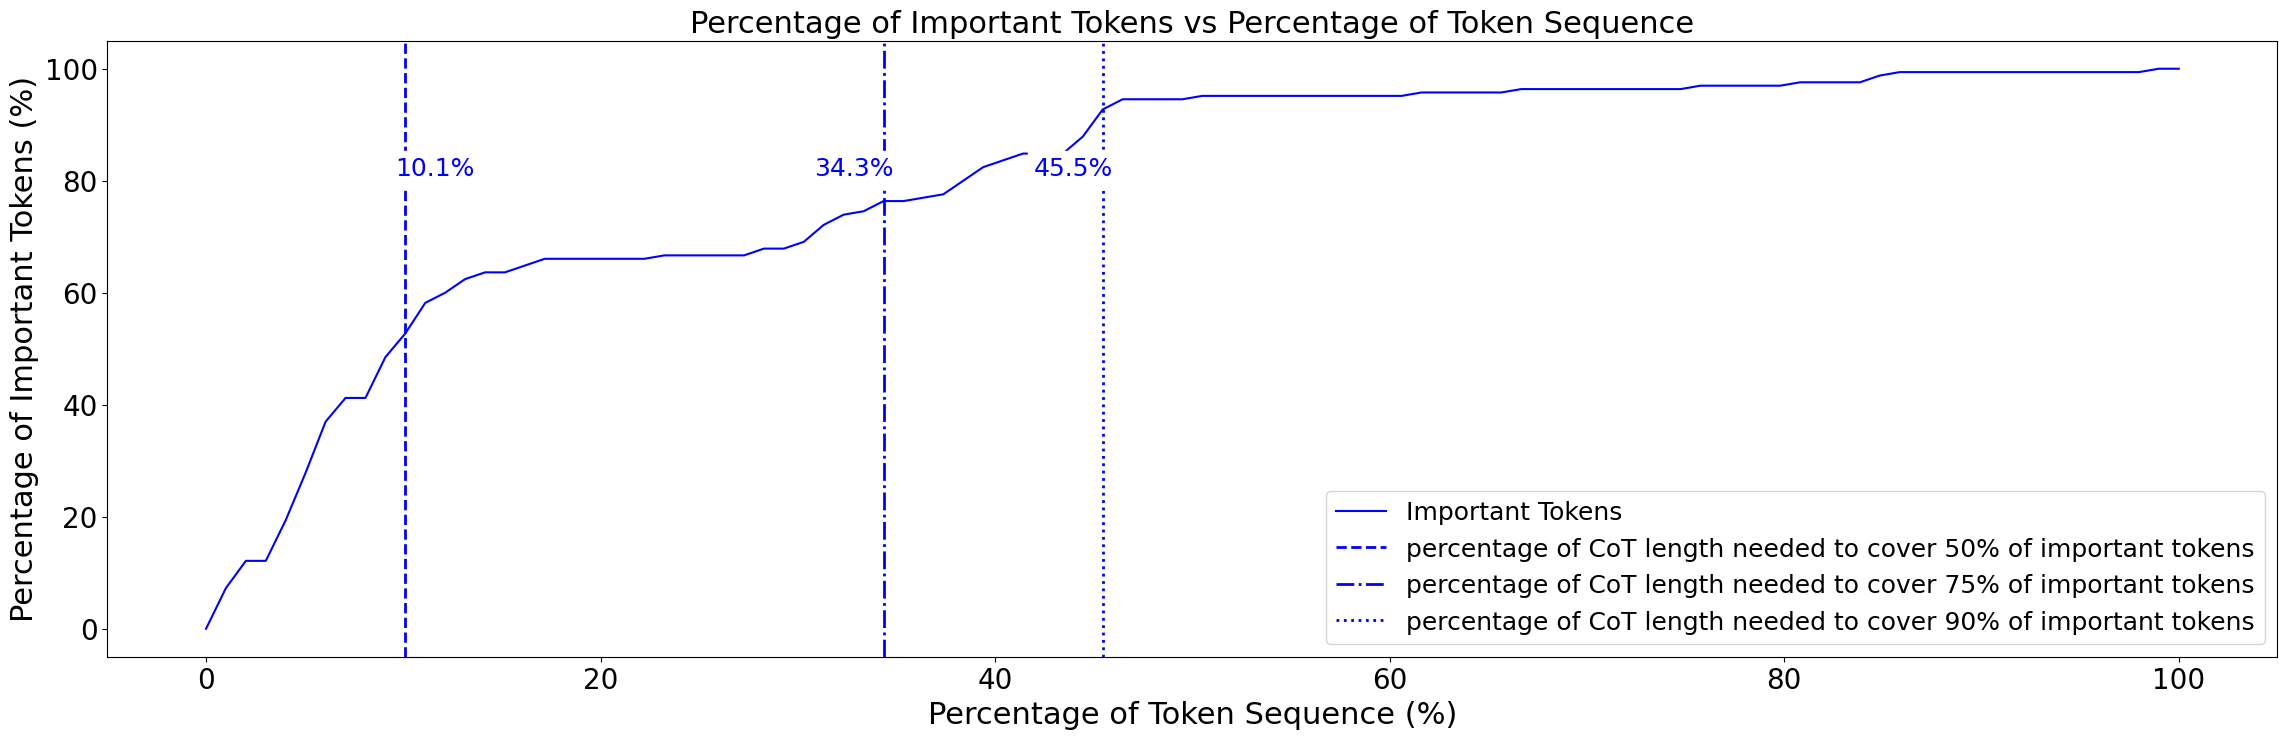

In [147]:
# how many non-zero importance tokens are within the first 20% of the token sequence?
threshold_index = int(0.2 * len(tok_importance_offsets))
count_in_first_20_percent = len(
    [
        i
        for i in high_importance_tokens
        if i < threshold_index
    ]
)
print(f"Found {count_in_first_20_percent} tokens with importance greater than {min_importance} within the first 20% of the token sequence")
print(f"Percentage: {count_in_first_20_percent / len(high_importance_tokens) * 100:.2f}%")

# PLOT 3 (percentage of important tokens over percentage of the token sequence)
plt.figure(figsize=(28, 8))
percentages = np.linspace(0, 1, 100)
important_token_counts = []
for p in percentages:
    threshold_index = int(p * len(tok_importance_offsets))
    count_in_percentage = len(
        [
            i
            for i in high_importance_tokens
            if i < threshold_index
        ]
    )
    important_token_counts.append(count_in_percentage / len(high_importance_tokens) * 100)
plt.plot(percentages * 100, important_token_counts, color="blue", label="Important Tokens")

important_token_counts_50_percent_index = np.where(np.array(important_token_counts) >= 50)[0][0]
important_token_counts_75_percent_index = np.where(np.array(important_token_counts) >= 75)[0][0]
important_token_counts_90_percent_index = np.where(np.array(important_token_counts) >= 90)[0][0]
plt.axvline(x=percentages[important_token_counts_50_percent_index]*100, color='blue', linestyle='--', linewidth=2, label='percentage of CoT length needed to cover 50% of important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_token_counts_50_percent_index] + 9.5,  # position near the right side of the plot
    y=important_token_counts[-1] * 0.8,               # a little above the line
    s=f"{percentages[important_token_counts_50_percent_index]*100:.1f}%",         # formatted text
    color='blue',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.axvline(x=percentages[important_token_counts_75_percent_index]*100, color='blue', linestyle='-.', linewidth=2, label='percentage of CoT length needed to cover 75% of important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_token_counts_75_percent_index] + 30.5,  # position near the right side of the plot
    y=important_token_counts[-1] * 0.8,               # a little above the line
    s=f"{percentages[important_token_counts_75_percent_index]*100:.1f}%",         # formatted text
    color='blue',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.axvline(x=percentages[important_token_counts_90_percent_index]*100, color='blue', linestyle=':', linewidth=2, label='percentage of CoT length needed to cover 90% of important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_token_counts_90_percent_index] + 41.5,  # position near the right side of the plot
    y=important_token_counts[-1] * 0.8,               # a little above the line
    s=f"{percentages[important_token_counts_90_percent_index]*100:.1f}%",         # formatted text
    color='blue',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.xlabel("Percentage of Token Sequence (%)")
# bigger axis labels text size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# bigger axis title text size
plt.xlabel("Percentage of Token Sequence (%)", fontsize=22)
plt.ylabel("Percentage of Important Tokens (%)", fontsize=22)
plt.title("Percentage of Important Tokens vs Percentage of Token Sequence", fontsize=22)
plt.legend(fontsize=18)
plt.show()

Found 17 sentences with importance greater than 0 within the first 20% of the sentence sequence
Percentage: 77.27%


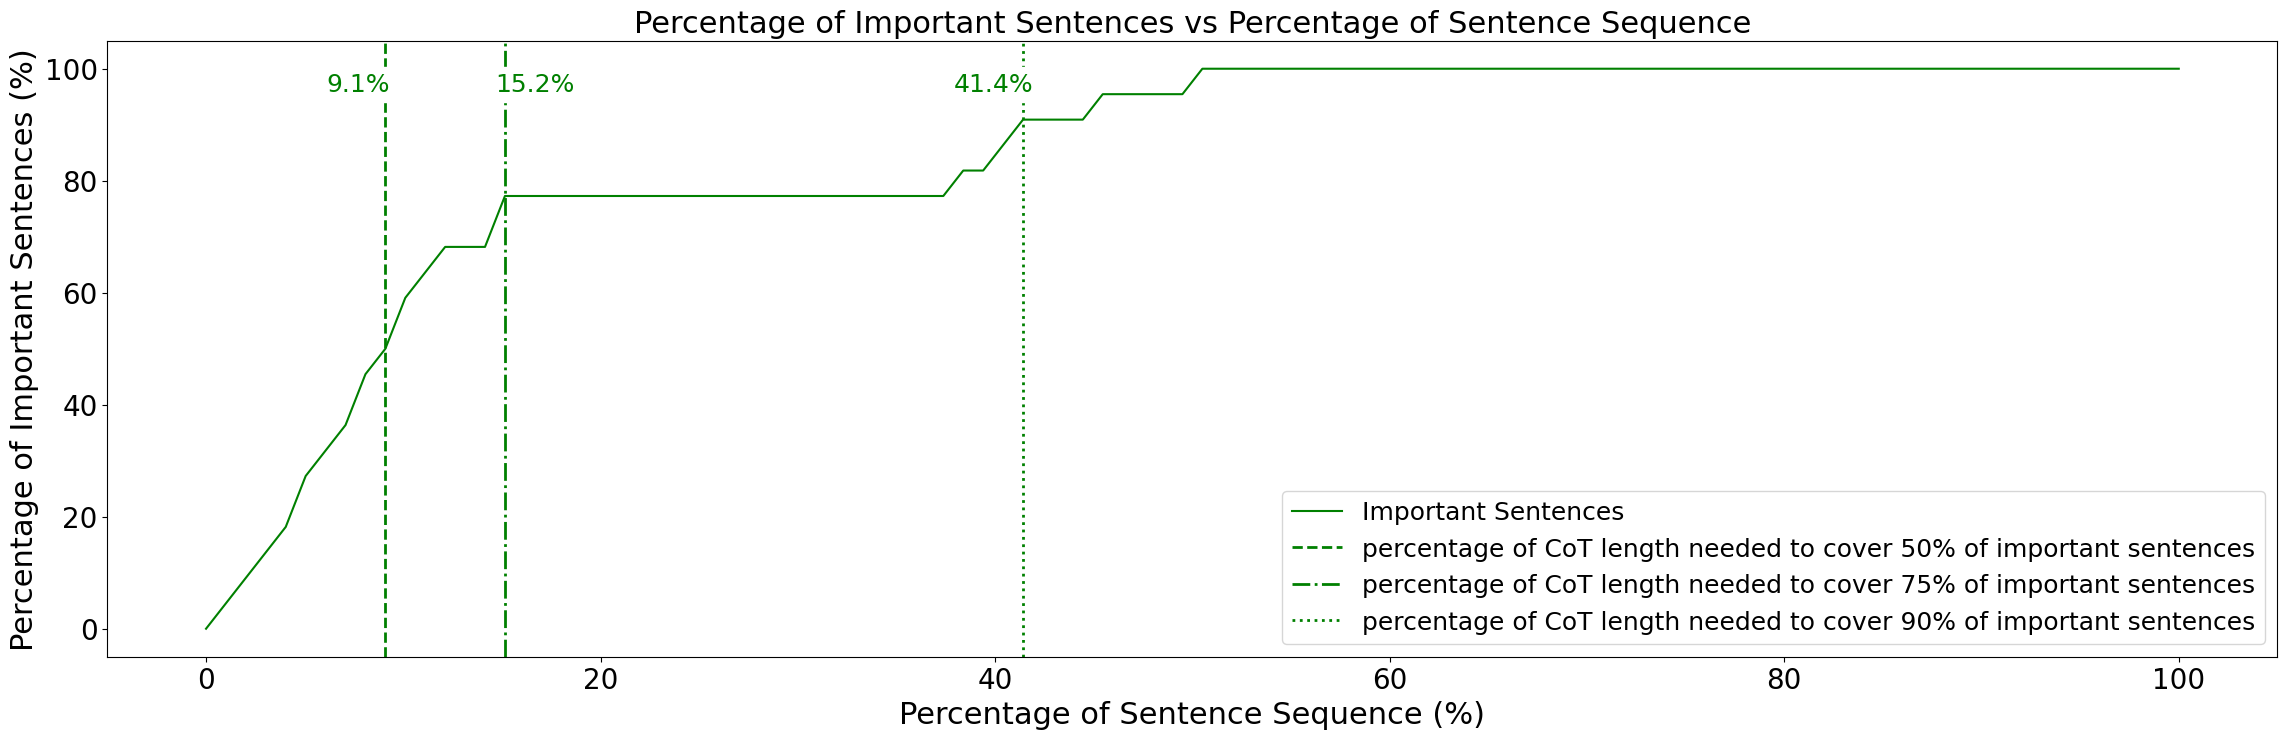

In [148]:
# how many non-zero importance sentences are within the first 20% of the token sequence?
min_importance = 0
high_importance_sentences = [
    i for i, (sent, imp, _, _) in enumerate(sent_importance_offsets) if np.abs(imp) > min_importance
]

threshold_index = int(0.2 * len(sent_importance_offsets))
count_in_first_20_percent = len(
    [
        i
        for i in high_importance_sentences
        if i < threshold_index
    ]
)

print(f"Found {count_in_first_20_percent} sentences with importance greater than {min_importance} within the first 20% of the sentence sequence")
print(f"Percentage: {count_in_first_20_percent / len(high_importance_sentences) * 100:.2f}%")

# PLOT 3 (percentage of important tokens over percentage of the token sequence)
plt.figure(figsize=(28, 8))
percentages = np.linspace(0, 1, 100)
important_sentence_counts = []
for p in percentages:
    threshold_index = int(p * len(sent_importance_offsets))
    count_in_percentage = len(
        [
            i
            for i in high_importance_sentences
            if i < threshold_index
        ]
    )
    important_sentence_counts.append(count_in_percentage / len(high_importance_sentences) * 100)
plt.plot(percentages * 100, important_sentence_counts, color="green", label="Important Sentences")

important_sentence_counts_50_percent_index = np.where(np.array(important_sentence_counts) >= 50)[0][0]
important_sentence_counts_75_percent_index = np.where(np.array(important_sentence_counts) >= 75)[0][0]
important_sentence_counts_90_percent_index = np.where(np.array(important_sentence_counts) >= 90)[0][0]
plt.axvline(x=percentages[important_sentence_counts_50_percent_index]*100, color='green', linestyle='--', linewidth=2, label='percentage of CoT length needed to cover 50% of important sentences')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_sentence_counts_50_percent_index] + 6,  # position near the right side of the plot
    y=important_sentence_counts[-1] * 0.95,               # a little above the line
    s=f"{percentages[important_sentence_counts_50_percent_index]*100:.1f}%",         # formatted text
    color='green',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.axvline(x=percentages[important_sentence_counts_75_percent_index]*100, color='green', linestyle='-.', linewidth=2, label='percentage of CoT length needed to cover 75% of important sentences')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_sentence_counts_75_percent_index] + 14.5,  # position near the right side of the plot
    y=important_sentence_counts[-1] * 0.95,               # a little above the line
    s=f"{percentages[important_sentence_counts_75_percent_index]*100:.1f}%",         # formatted text
    color='green',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.axvline(x=percentages[important_sentence_counts_90_percent_index]*100, color='green', linestyle=':', linewidth=2, label='percentage of CoT length needed to cover 90% of important sentences')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_sentence_counts_90_percent_index] + 37.5,  # position near the right side of the plot
    y=important_sentence_counts[-1] * 0.95,               # a little above the line
    s=f"{percentages[important_sentence_counts_90_percent_index]*100:.1f}%",         # formatted text
    color='green',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.xlabel("Percentage of Sentence Sequence (%)")
# bigger axis labels text size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# bigger axis title text size
plt.xlabel("Percentage of Sentence Sequence (%)", fontsize=22)
plt.ylabel("Percentage of Important Sentences (%)", fontsize=22)
plt.title("Percentage of Important Sentences vs Percentage of Sentence Sequence", fontsize=22)
plt.legend(fontsize=18)
plt.show()

Found 109 tokens with importance greater than 0 within the first 20% of the token sequence
Percentage: 66.06%
Found 17 sentences with importance greater than 0 within the first 20% of the sentence sequence
Percentage: 77.27%


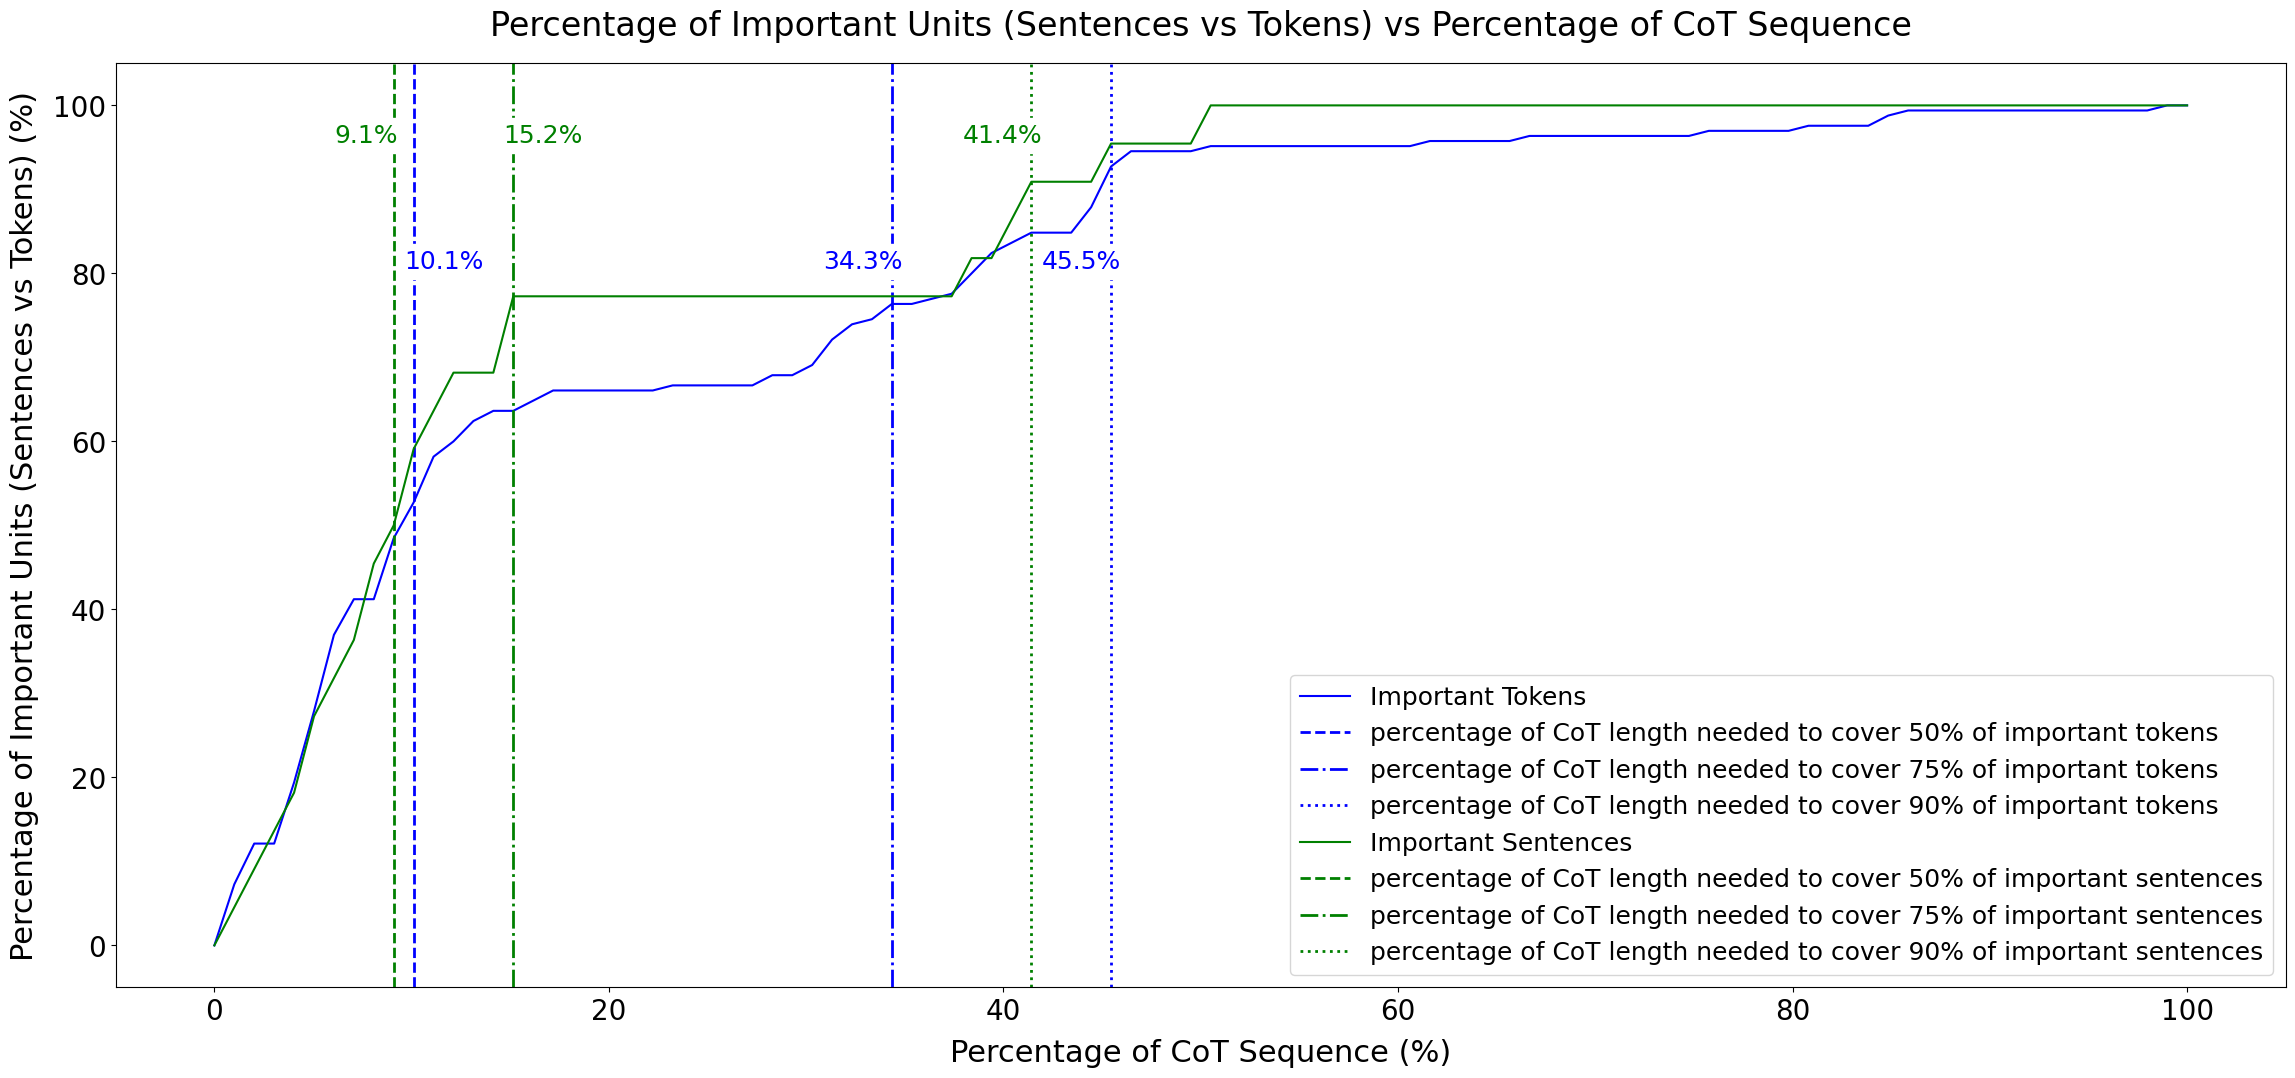

In [149]:
# how many non-zero importance tokens are within the first 20% of the token sequence?
threshold_index = int(0.2 * len(tok_importance_offsets))
count_in_first_20_percent = len(
    [
        i
        for i in high_importance_tokens
        if i < threshold_index
    ]
)
print(f"Found {count_in_first_20_percent} tokens with importance greater than {min_importance} within the first 20% of the token sequence")
print(f"Percentage: {count_in_first_20_percent / len(high_importance_tokens) * 100:.2f}%")

# PLOT 3 (percentage of important tokens over percentage of the token sequence)
plt.figure(figsize=(28, 12))
percentages = np.linspace(0, 1, 100)
important_token_counts = []
for p in percentages:
    threshold_index = int(p * len(tok_importance_offsets))
    count_in_percentage = len(
        [
            i
            for i in high_importance_tokens
            if i < threshold_index
        ]
    )
    important_token_counts.append(count_in_percentage / len(high_importance_tokens) * 100)
plt.plot(percentages * 100, important_token_counts, color="blue", label="Important Tokens")

important_token_counts_50_percent_index = np.where(np.array(important_token_counts) >= 50)[0][0]
important_token_counts_75_percent_index = np.where(np.array(important_token_counts) >= 75)[0][0]
important_token_counts_90_percent_index = np.where(np.array(important_token_counts) >= 90)[0][0]
plt.axvline(x=percentages[important_token_counts_50_percent_index]*100, color='blue', linestyle='--', linewidth=2, label='percentage of CoT length needed to cover 50% of important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_token_counts_50_percent_index] + 9.5,  # position near the right side of the plot
    y=important_token_counts[-1] * 0.8,               # a little above the line
    s=f"{percentages[important_token_counts_50_percent_index]*100:.1f}%",         # formatted text
    color='blue',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.axvline(x=percentages[important_token_counts_75_percent_index]*100, color='blue', linestyle='-.', linewidth=2, label='percentage of CoT length needed to cover 75% of important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_token_counts_75_percent_index] + 30.5,  # position near the right side of the plot
    y=important_token_counts[-1] * 0.8,               # a little above the line
    s=f"{percentages[important_token_counts_75_percent_index]*100:.1f}%",         # formatted text
    color='blue',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.axvline(x=percentages[important_token_counts_90_percent_index]*100, color='blue', linestyle=':', linewidth=2, label='percentage of CoT length needed to cover 90% of important tokens')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_token_counts_90_percent_index] + 41.5,  # position near the right side of the plot
    y=important_token_counts[-1] * 0.8,               # a little above the line
    s=f"{percentages[important_token_counts_90_percent_index]*100:.1f}%",         # formatted text
    color='blue',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

# how many non-zero importance sentences are within the first 20% of the token sequence?
min_importance = 0
high_importance_sentences = [
    i for i, (sent, imp, _, _) in enumerate(sent_importance_offsets) if np.abs(imp) > min_importance
]

threshold_index = int(0.2 * len(sent_importance_offsets))
count_in_first_20_percent = len(
    [
        i
        for i in high_importance_sentences
        if i < threshold_index
    ]
)

print(f"Found {count_in_first_20_percent} sentences with importance greater than {min_importance} within the first 20% of the sentence sequence")
print(f"Percentage: {count_in_first_20_percent / len(high_importance_sentences) * 100:.2f}%")

# PLOT 3 (percentage of important tokens over percentage of the token sequence)
#plt.figure(figsize=(28, 8))
percentages = np.linspace(0, 1, 100)
important_sentence_counts = []
for p in percentages:
    threshold_index = int(p * len(sent_importance_offsets))
    count_in_percentage = len(
        [
            i
            for i in high_importance_sentences
            if i < threshold_index
        ]
    )
    important_sentence_counts.append(count_in_percentage / len(high_importance_sentences) * 100)
plt.plot(percentages * 100, important_sentence_counts, color="green", label="Important Sentences")

important_sentence_counts_50_percent_index = np.where(np.array(important_sentence_counts) >= 50)[0][0]
important_sentence_counts_75_percent_index = np.where(np.array(important_sentence_counts) >= 75)[0][0]
important_sentence_counts_90_percent_index = np.where(np.array(important_sentence_counts) >= 90)[0][0]
plt.axvline(x=percentages[important_sentence_counts_50_percent_index]*100, color='green', linestyle='--', linewidth=2, label='percentage of CoT length needed to cover 50% of important sentences')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_sentence_counts_50_percent_index] + 6,  # position near the right side of the plot
    y=important_sentence_counts[-1] * 0.95,               # a little above the line
    s=f"{percentages[important_sentence_counts_50_percent_index]*100:.1f}%",         # formatted text
    color='green',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.axvline(x=percentages[important_sentence_counts_75_percent_index]*100, color='green', linestyle='-.', linewidth=2, label='percentage of CoT length needed to cover 75% of important sentences')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_sentence_counts_75_percent_index] + 14.5,  # position near the right side of the plot
    y=important_sentence_counts[-1] * 0.95,               # a little above the line
    s=f"{percentages[important_sentence_counts_75_percent_index]*100:.1f}%",         # formatted text
    color='green',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

plt.axvline(x=percentages[important_sentence_counts_90_percent_index]*100, color='green', linestyle=':', linewidth=2, label='percentage of CoT length needed to cover 90% of important sentences')
# ✅ Annotate the y-value on top of the line
plt.text(
    x=percentages[important_sentence_counts_90_percent_index] + 37.5,  # position near the right side of the plot
    y=important_sentence_counts[-1] * 0.95,               # a little above the line
    s=f"{percentages[important_sentence_counts_90_percent_index]*100:.1f}%",         # formatted text
    color='green',
    fontsize=18,
    ha='left',
    va='bottom',
    backgroundcolor='white'         # makes it readable
)

# bigger axis labels text size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# bigger axis title text size
plt.xlabel("Percentage of CoT Sequence (%)", fontsize=22, labelpad=10)
plt.ylabel("Percentage of Important Units (Sentences vs Tokens) (%)", fontsize=22, labelpad=10)
plt.title("Percentage of Important Units (Sentences vs Tokens) vs Percentage of CoT Sequence", fontsize=24, pad=20)
plt.legend(fontsize=18)
plt.show()

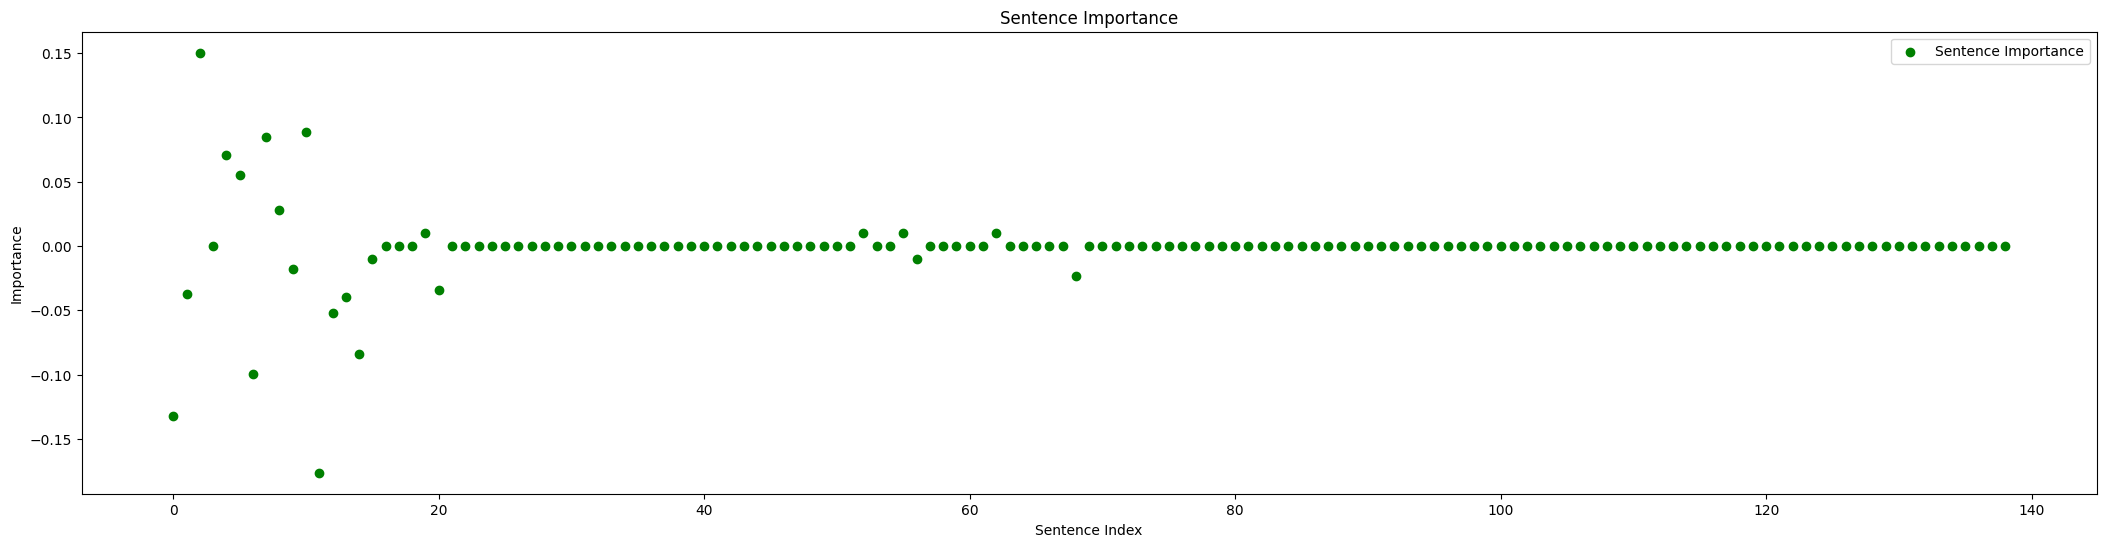

In [150]:

# PLOT 3 (sentence importance scatter plot)
plt.figure(figsize=(26, 6))
plt.scatter(
    range(len(sent_importances)),
    sent_importances,
    color="green",
    label="Sentence Importance",
)
plt.xlabel("Sentence Index")
plt.ylabel("Importance")
plt.title("Sentence Importance")
plt.legend()
plt.show()


Threshold for top 80th percentile: 0.0


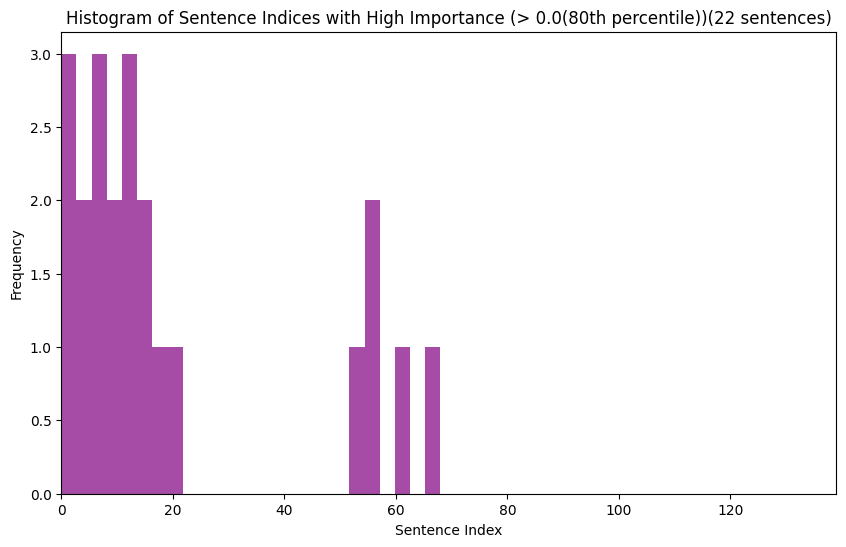

In [151]:
# PLOT 4 (histogram of most important sentences indices)

percentile = 80
threshold = np.percentile(
    [np.abs(sent_importances[i]) for i in range(len(sent_importances))],
    percentile,
)   
print(f"Threshold for top {percentile}th percentile: {threshold}")
# take all non-zero importance sentences
#threshold = 0

plt.figure(figsize=(10, 6))
plt.hist(
    [i for i in range(len(sent_importances)) if np.abs(sent_importances[i]) > threshold],
    bins=25,
    color="purple",
    alpha=0.7,
)
plt.xlim(0, len(sent_importances))
plt.xlabel("Sentence Index")
plt.ylabel("Frequency")
plt.title(f"Histogram of Sentence Indices with High Importance (> {threshold}({percentile}th percentile))({len([i for i in range(len(sent_importances)) if np.abs(sent_importances[i]) > threshold])} sentences)")
plt.show()


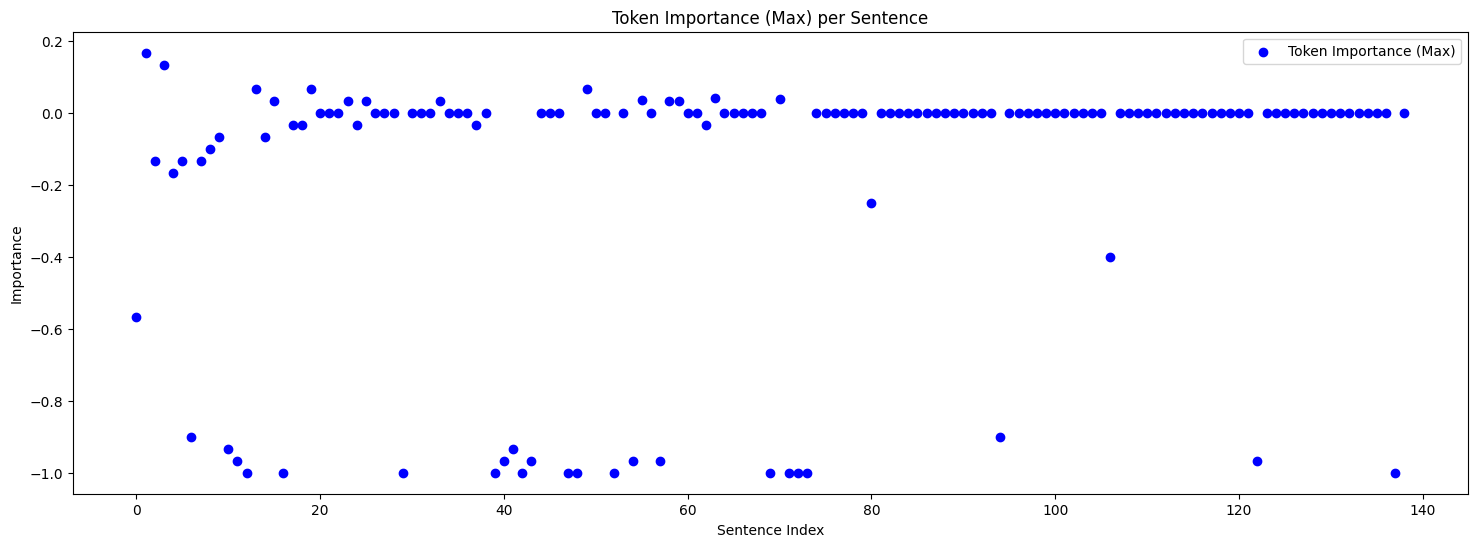

In [152]:

# PLOT 3 (token importance per sentence scatter plot)
plt.figure(figsize=(18, 6))
plt.scatter(
    range(len(max_token_importances)),
    max_token_importances,
    color="blue",
    label="Token Importance (Max)",
)
plt.xlabel("Sentence Index")
plt.ylabel("Importance")
plt.title("Token Importance (Max) per Sentence")
plt.legend()
plt.show()


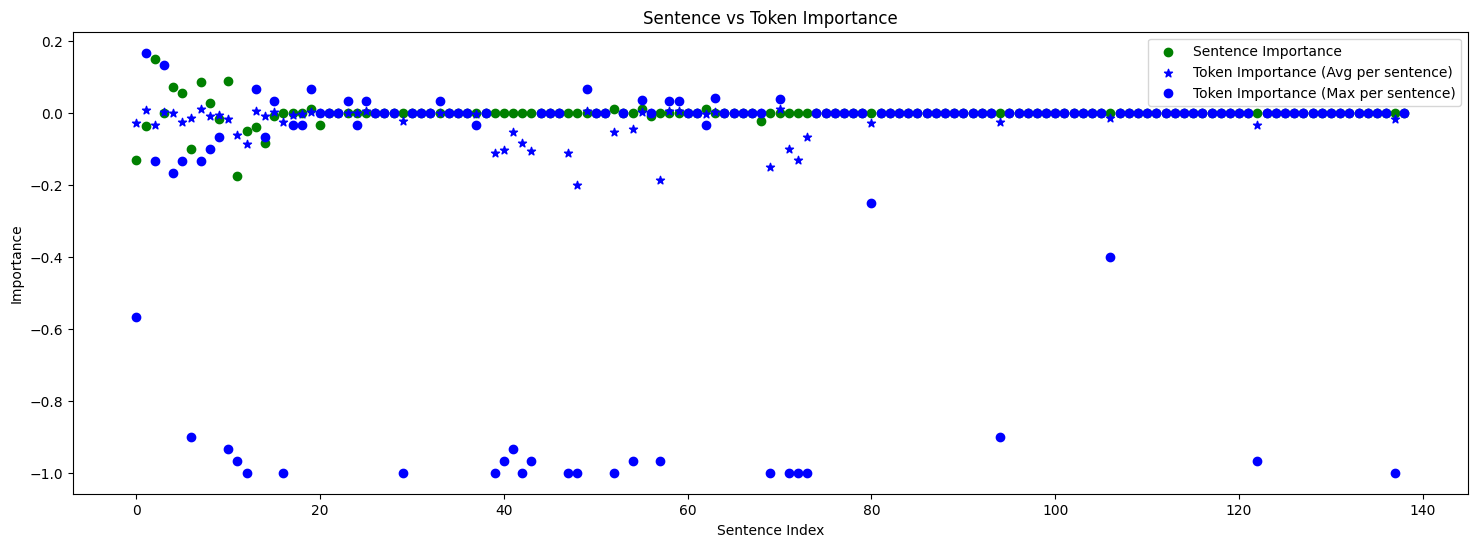

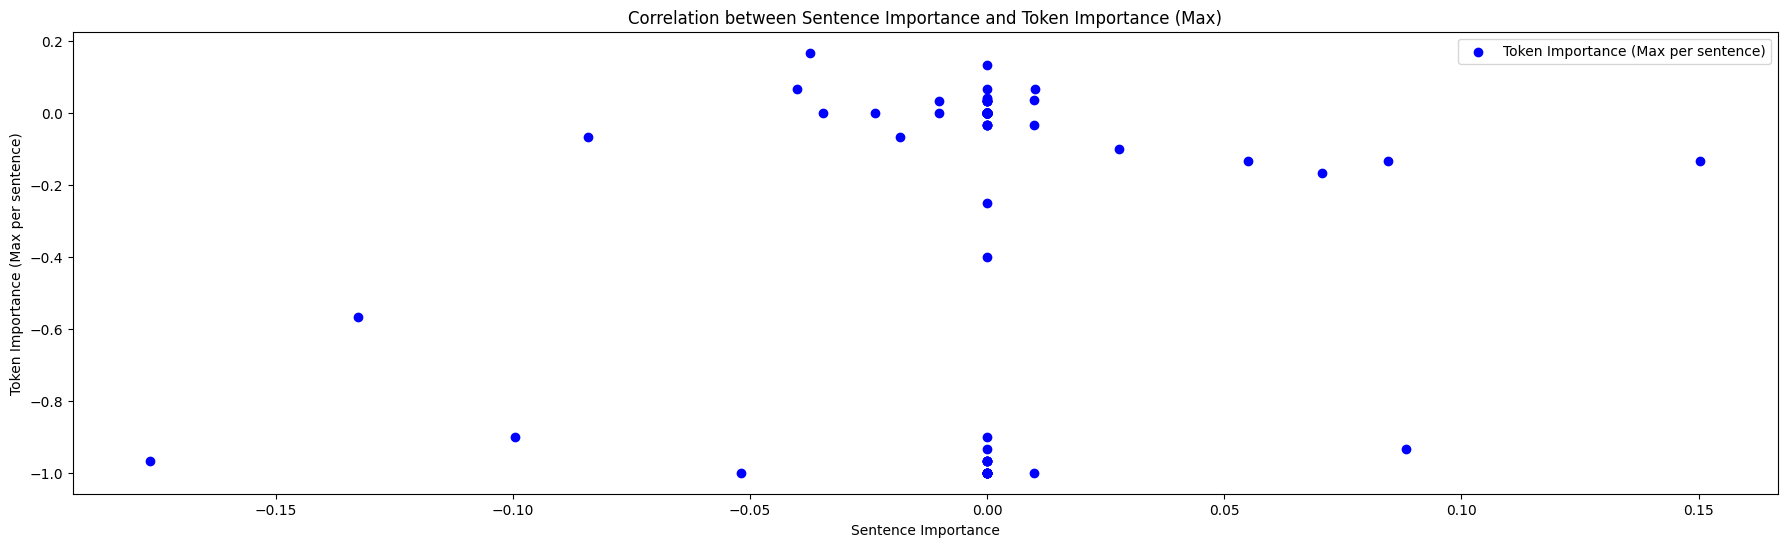

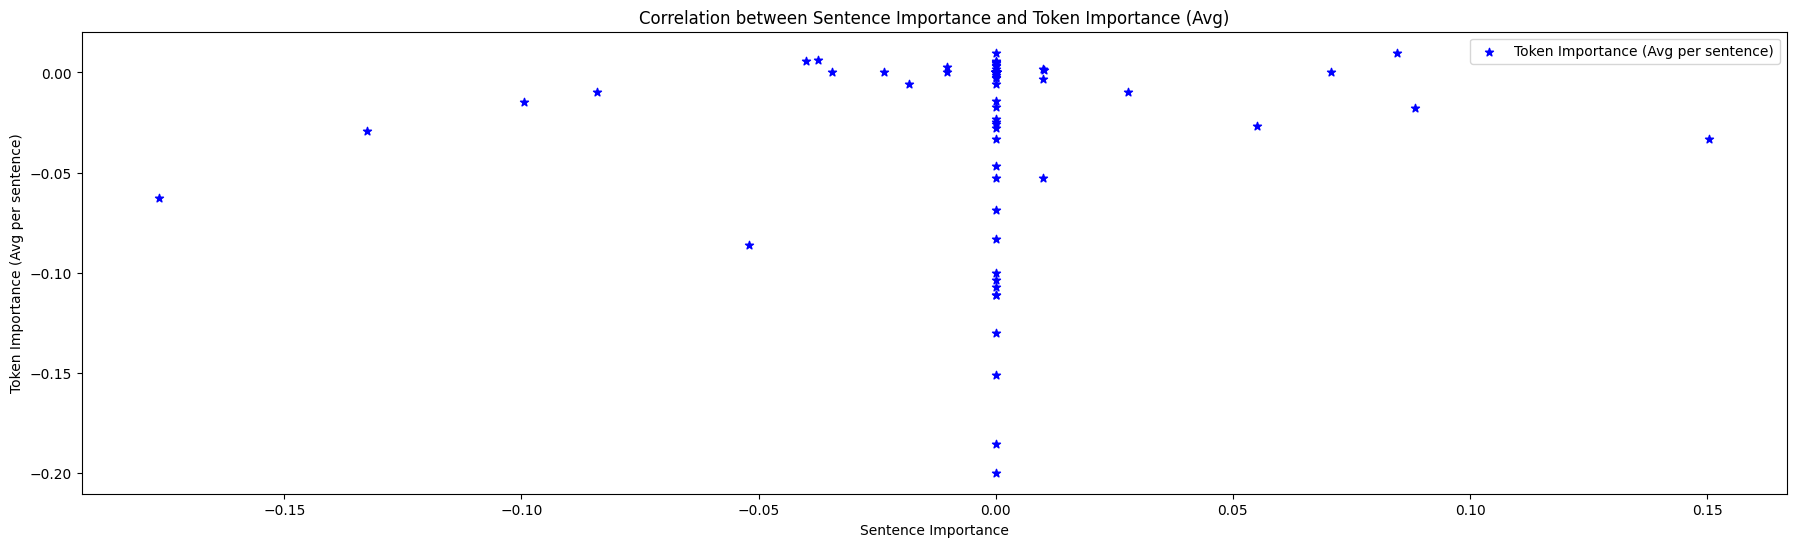

In [153]:

# PLOT 4 (token vs sentence importances)
# now I want to plot these importances in a scatter plot where the x axis is the sentence index and the y axis is the importance, in blue the sentence importance and in different greens the token-based importance (avg/max/total)

plt.figure(figsize=(18, 6))
plt.scatter(
    range(len(sent_importances)),
    sent_importances,
    color="green",
    marker="o",
    label="Sentence Importance",
)

plt.scatter(
    range(len(avg_token_importances)),
    avg_token_importances,
    color="blue",
    marker="*",
    label="Token Importance (Avg per sentence)",
)
plt.scatter(
    range(len(max_token_importances)),
    max_token_importances,
    color="blue",
    marker="o",
    label="Token Importance (Max per sentence)",
)
"""
plt.scatter(
    range(len(total_token_importances)),
    total_token_importances,
    color="darkgreen",
    label="Token Importance (Total)",
    alpha=0.9,
)
"""
plt.xlabel("Sentence Index")
plt.ylabel("Importance")
plt.title("Sentence vs Token Importance")
plt.legend()
plt.show()

# now plot the correlation between sentence importance and token importance (max) as a scatter plot
plt.figure(figsize=(22, 6))
plt.scatter(
    sent_importances,
    max_token_importances,
    color="blue",
    label="Token Importance (Max per sentence)",
)
plt.xlabel("Sentence Importance")
plt.ylabel("Token Importance (Max per sentence)")
plt.title("Correlation between Sentence Importance and Token Importance (Max)")
plt.legend()
plt.show()

plt.figure(figsize=(22, 6))
plt.scatter(
    sent_importances,
    avg_token_importances,
    color="blue",
    marker="*",
    label="Token Importance (Avg per sentence)",
)
plt.xlabel("Sentence Importance")
plt.ylabel("Token Importance (Avg per sentence)")
plt.title("Correlation between Sentence Importance and Token Importance (Avg)")
plt.legend()
plt.show()

In [154]:
stats.pearsonr(sent_importances, max_token_importances)

PearsonRResult(statistic=np.float64(0.13715837570605913), pvalue=np.float64(0.10737825195991361))

In [155]:
stats.spearmanr(sent_importances, max_token_importances)

SignificanceResult(statistic=np.float64(-0.08091528633722504), pvalue=np.float64(0.34368142032618754))

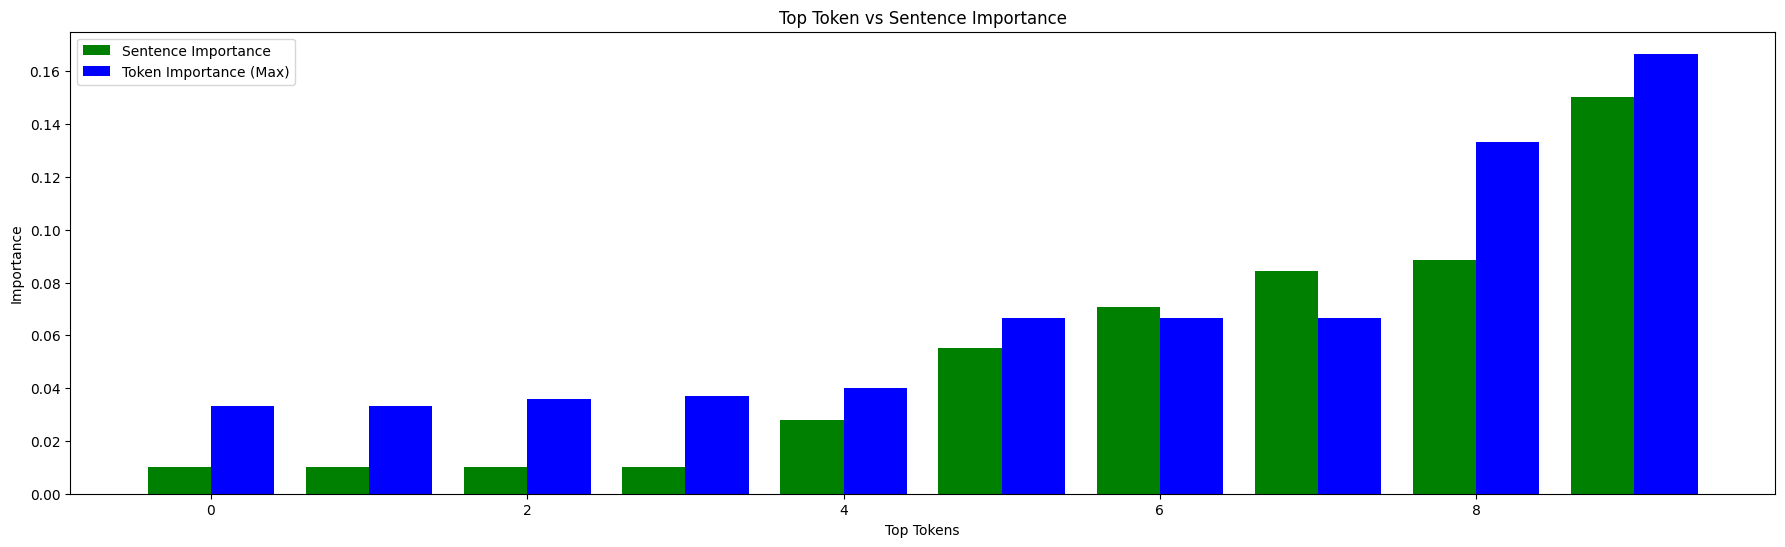

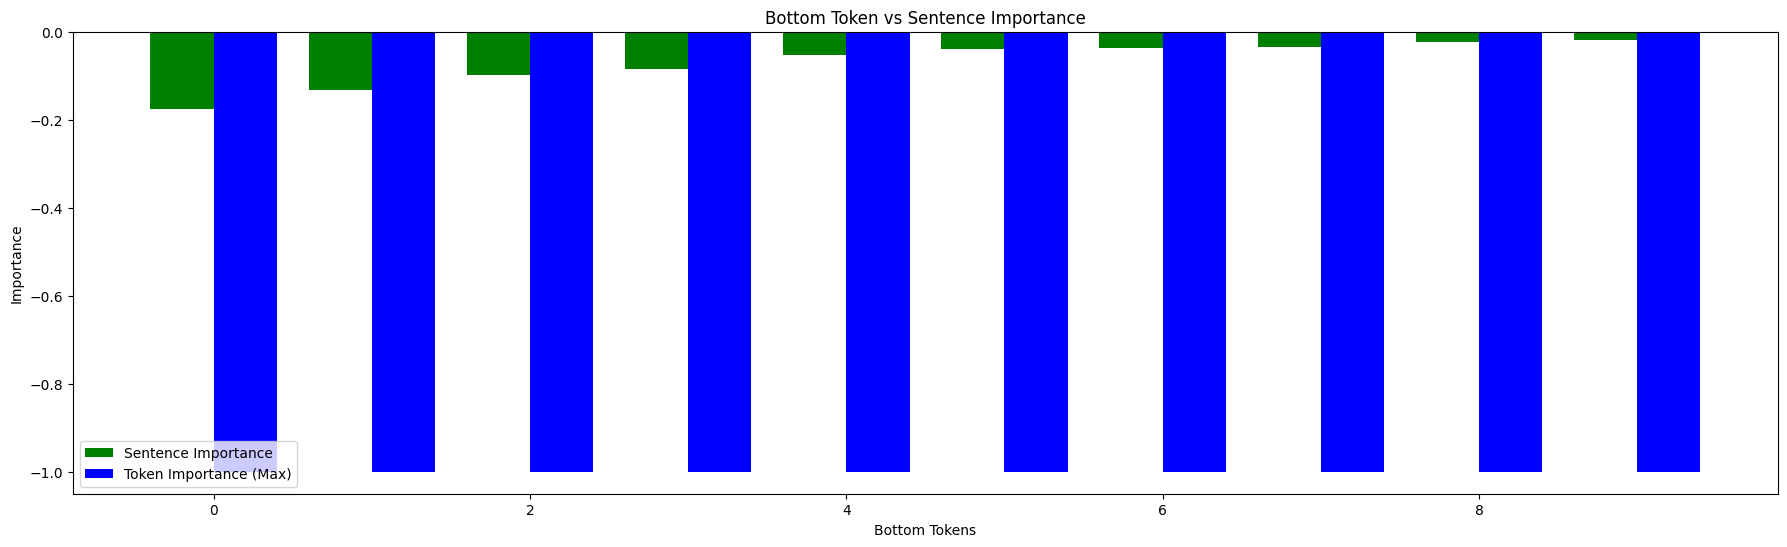

In [156]:
# here I want to compare the top importance values for the sentence level decomposition with those of the token level analysis
# add to the bars the token/sentence index as text labels
top_n = 10
top_sent_importances = np.argsort(sent_importances)[-top_n:]
top_token_importances = np.argsort(max_token_importances)[-top_n:]

plt.figure(figsize=(22, 6))
# plot the bar plots side by side
plt.bar(
    np.arange(top_n) - 0.2,
    [sent_importances[i] for i in top_sent_importances],
    width=0.4,
    color="green",
    label="Sentence Importance",
)
plt.bar(
    np.arange(top_n) + 0.2,
    [max_token_importances[i] for i in top_token_importances],
    width=0.4,
    color="blue",
    label="Token Importance (Max)",
)
plt.xlabel("Top Tokens")
plt.ylabel("Importance")
plt.title("Top Token vs Sentence Importance")
plt.legend()
plt.show()

# now plot the lowest importance values for the sentence level decomposition with those of the token level analysis
bottom_n = 10
bottom_sent_importances = np.argsort(sent_importances)[:bottom_n]
bottom_token_importances = np.argsort(max_token_importances)[:bottom_n]
plt.figure(figsize=(22, 6))
# plot the bar plots side by side
plt.bar(
    np.arange(bottom_n) - 0.2,
    [sent_importances[i] for i in bottom_sent_importances],
    width=0.4,
    color="green",
    label="Sentence Importance",
)
plt.bar(
    np.arange(bottom_n) + 0.2,
    [max_token_importances[i] for i in bottom_token_importances],
    width=0.4,
    color="blue",
    label="Token Importance (Max)",
)
plt.xlabel("Bottom Tokens")
plt.ylabel("Importance")
plt.title("Bottom Token vs Sentence Importance")
plt.legend()
plt.show()
    
    

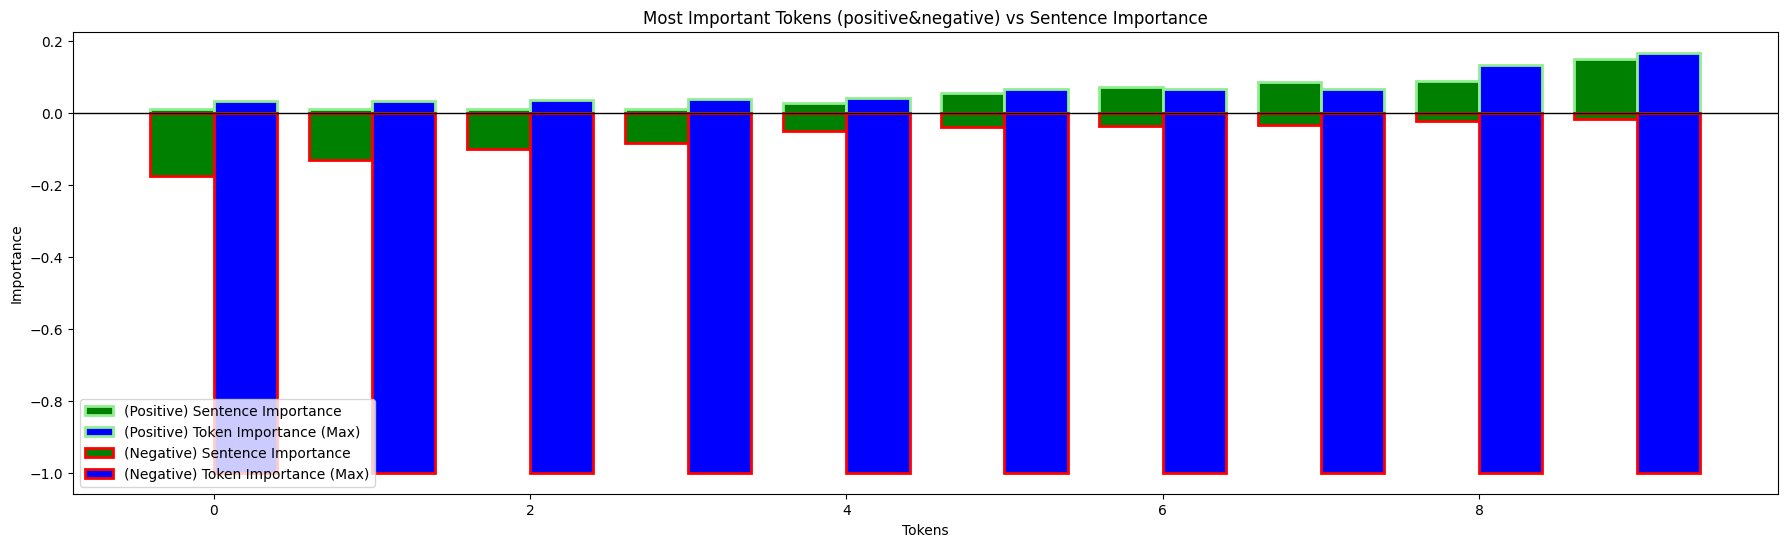

In [157]:
# here I want to compare the top importance values for the sentence level decomposition with those of the token level analysis
# add to the bars the token/sentence index as text labels
top_n = 10
top_sent_importances = np.argsort(sent_importances)[-top_n:]
top_token_importances = np.argsort(max_token_importances)[-top_n:]
# now plot the lowest importance values for the sentence level decomposition with those of the token level analysis
bottom_n = 10
bottom_sent_importances = np.argsort(sent_importances)[:bottom_n]
bottom_token_importances = np.argsort(max_token_importances)[:bottom_n]

plt.figure(figsize=(22, 6))
# plot the bar plots side by side
plt.bar(
    np.arange(top_n) - 0.2,
    [sent_importances[i] for i in top_sent_importances],
    width=0.4,
    color="green",
    label="(Positive) Sentence Importance",
    edgecolor="lightgreen",
    linewidth=2,
)
plt.bar(
    np.arange(top_n) + 0.2,
    [max_token_importances[i] for i in top_token_importances],
    width=0.4,
    color="blue",
    label="(Positive) Token Importance (Max)",
    edgecolor="lightgreen",
    linewidth=2,
)

# plot the bar plots side by side
plt.bar(
    np.arange(bottom_n) - 0.2,
    [sent_importances[i] for i in bottom_sent_importances],
    width=0.4,
    color="green",
    label="(Negative) Sentence Importance",
    edgecolor="red",
    linewidth=2,
)
plt.bar(
    np.arange(bottom_n) + 0.2,
    [max_token_importances[i] for i in bottom_token_importances],
    width=0.4,
    color="blue",
    label="(Negative) Token Importance (Max)",
    edgecolor="red",
    linewidth=2,
)
# draw a horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel("Tokens")
plt.ylabel("Importance")
plt.title("Most Important Tokens (positive&negative) vs Sentence Importance")
plt.legend()
plt.show()
    
    

In [158]:
print(sent_importance_offsets[0:10])
print(tok_importance_offsets[0:10])

[("Okay, so I've got this math problem here that I need to solve.", -0.13261480787253987, 0, 62), ("It looks a bit complicated at first glance, but maybe if I break it down step by step, it'll make more sense.", -0.03737373737373739, 63, 172), ('The problem is:', 0.15039929015084297, 173, 188), ('Compute $3(1+3(1+3(1+3(1+3(1+3(1+3(1+3(1+3(1+3)))))))))$', 0.0, 190, 247), ("Wow, that's a lot of parentheses and threes.", 0.07070707070707072, 249, 293), ('Let me see if I can figure this out.', 0.055102040816326525, 294, 330), ('First, I notice that the expression is a nested set of terms where each term is 1 plus 3 times another similar expression.', -0.09941520467836251, 332, 454), ("It seems like there's a repeating pattern here, which might mean that I can solve it by working from the innermost parentheses outward.", 0.0845164152617569, 455, 590), ('That makes sense because each opening parenthesis must be closed eventually, so starting from the inside would be logical.', 0.027856986181

=== Correlations (token-level) ===
Pearson(token, sentence): 0.034011511235363265
Spearman(token, sentence): -0.0015927869954043905
Pearson(|token|, |sentence|): 0.08933571824445033
Spearman(|token|, |sentence|): 0.3457415151002631

=== Correlations (sentence vs aggregated token importance) ===
Pearson(sentence, mean token): 0.10523515225018962
Spearman(sentence, mean token): -0.015315418657230531
Pearson(sentence, max token): -0.2081449214976254
Spearman(sentence, max token): -0.16631139158701086
Pearson(|sentence|, max |token|): 0.218480138377884
Spearman(|sentence|, max |token|): 0.37903774501143006

=== Top-10% overlap metrics ===
Fraction of important tokens in important sentences: 0.09726962457337884
Fraction of important sentences with ≥1 important token: 1.0
Jaccard overlap of important sentence sets: 0.09352517985611511


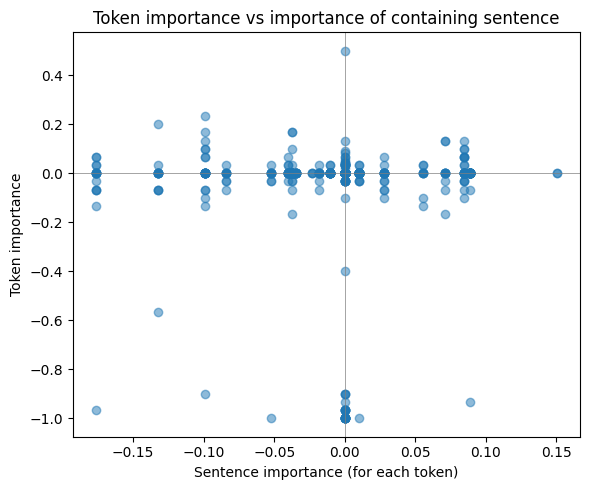

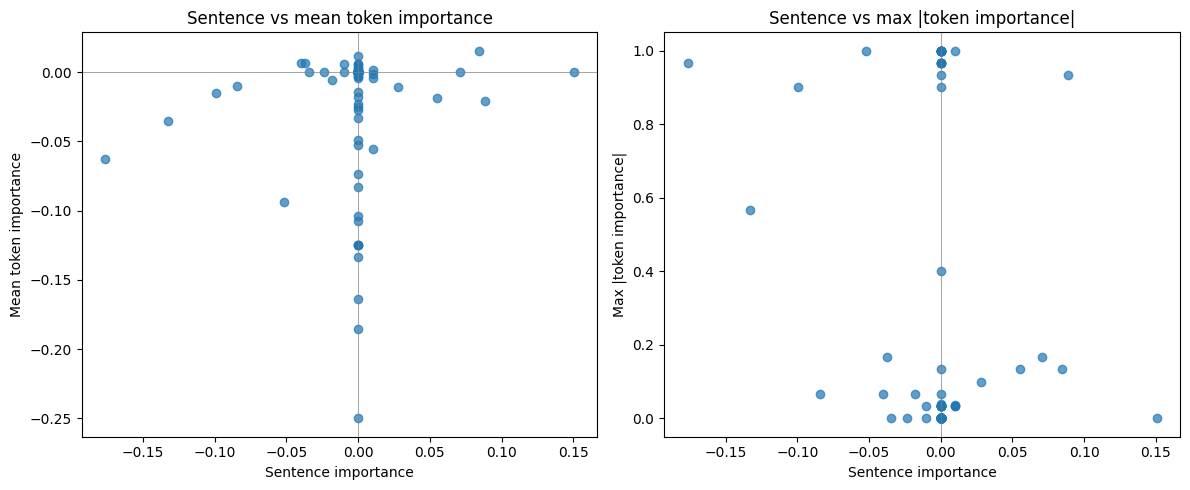

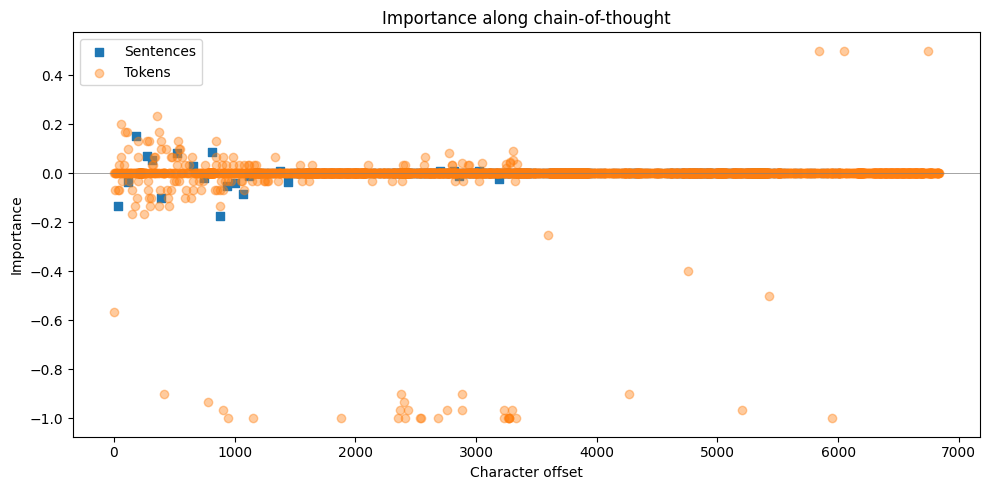

In [159]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# 1. Helper functions
# ---------------------------------------------------------------------

def map_tokens_to_sentences(sent_importance_offsets, tok_importance_offsets):
    """
    Map each token to the index of the sentence that contains it.
    Both lists contain (text, importance, start_offset, end_offset).
    Returns: list[int or None] of length len(tok_importance_offsets).
    """
    sent_spans = [(s[2], s[3]) for s in sent_importance_offsets]
    token_to_sentence = []

    j = 0  # pointer into sentences, assuming they are sorted by offset
    for (_, _, t_start, t_end) in tok_importance_offsets:
        # advance sentence pointer if token starts after the end of current sentence
        while j + 1 < len(sent_spans) and t_start >= sent_spans[j][1]:
            j += 1

        s_start, s_end = sent_spans[j]
        if s_start <= t_start and t_end <= s_end:
            token_to_sentence.append(j)
        else:
            # fallback: linear search (in case of weird overlaps)
            found = None
            for k, (ss, ee) in enumerate(sent_spans):
                if ss <= t_start and t_end <= ee:
                    found = k
                    break
            token_to_sentence.append(found)

    return token_to_sentence


def safe_corr(x, y):
    """Pearson correlation with basic safety checks."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan
    if np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan
    return np.corrcoef(x, y)[0, 1]


def rankdata(a):
    """
    Simple rank implementation (average rank for ties).
    Returns ranks starting from 0.
    """
    a = np.asarray(a, dtype=float)
    order = np.argsort(a)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(a))

    # handle ties: average ranks
    values, inv, counts = np.unique(a, return_inverse=True, return_counts=True)
    sums = np.bincount(inv, ranks)
    avg_ranks = sums / counts
    return avg_ranks[inv]


def spearmanr(x, y):
    """Spearman correlation (correlation of ranks)."""
    rx = rankdata(x)
    ry = rankdata(y)
    return safe_corr(rx, ry)


# ---------------------------------------------------------------------
# 2. Core metrics
# ---------------------------------------------------------------------

def compute_metrics(sent_importance_offsets, tok_importance_offsets, top_fraction=0.1):
    """
    Compute correlation/overlap between sentence-level and token-level importances.
    Returns:
      metrics: dict of numeric metrics
      aux: dict of arrays useful for plotting
    """
    sent_scores = np.array([s[1] for s in sent_importance_offsets], dtype=float)
    tok_scores = np.array([t[1] for t in tok_importance_offsets], dtype=float)

    token_to_sentence_list = map_tokens_to_sentences(
        sent_importance_offsets, tok_importance_offsets
    )
    valid_mask = np.array([idx is not None for idx in token_to_sentence_list])
    # replace None with -1 for convenience
    token_to_sentence = np.array(
        [idx if idx is not None else -1 for idx in token_to_sentence_list],
        dtype=int
    )

    # ------------------ token-level view ------------------
    tok_scores_valid = tok_scores[valid_mask]
    sent_for_tok_scores = sent_scores[token_to_sentence[valid_mask]]

    metrics = {}

    metrics["pearson_token_vs_sentence"] = safe_corr(
        tok_scores_valid, sent_for_tok_scores
    )
    metrics["spearman_token_vs_sentence"] = spearmanr(
        tok_scores_valid, sent_for_tok_scores
    )

    metrics["pearson_abs_token_vs_sentence"] = safe_corr(
        np.abs(tok_scores_valid), np.abs(sent_for_tok_scores)
    )
    metrics["spearman_abs_token_vs_sentence"] = spearmanr(
        np.abs(tok_scores_valid), np.abs(sent_for_tok_scores)
    )

    # ------------------ sentence-level aggregation ------------------
    n_sent = len(sent_scores)
    mean_tok_per_sent = np.zeros(n_sent, dtype=float)
    max_tok_per_sent = np.zeros(n_sent, dtype=float)
    abs_max_tok_per_sent = np.zeros(n_sent, dtype=float)
    counts = np.zeros(n_sent, dtype=int)

    for t_idx, s_idx in enumerate(token_to_sentence):
        if s_idx < 0:
            continue
        counts[s_idx] += 1
        val = tok_scores[t_idx]
        if counts[s_idx] == 1:
            mean_tok_per_sent[s_idx] = val
            max_tok_per_sent[s_idx] = val
            abs_max_tok_per_sent[s_idx] = abs(val)
        else:
            mean_tok_per_sent[s_idx] += val
            if val > max_tok_per_sent[s_idx]:
                max_tok_per_sent[s_idx] = val
            if abs(val) > abs_max_tok_per_sent[s_idx]:
                abs_max_tok_per_sent[s_idx] = abs(val)

    # finalize means, set NaN where no tokens
    has_tokens = counts > 0
    mean_tok_per_sent[has_tokens] /= counts[has_tokens]
    mean_tok_per_sent[~has_tokens] = np.nan
    max_tok_per_sent[~has_tokens] = np.nan
    abs_max_tok_per_sent[~has_tokens] = np.nan

    valid_sent_idx = has_tokens

    metrics["pearson_sentence_vs_mean_token"] = safe_corr(
        sent_scores[valid_sent_idx], mean_tok_per_sent[valid_sent_idx]
    )
    metrics["spearman_sentence_vs_mean_token"] = spearmanr(
        sent_scores[valid_sent_idx], mean_tok_per_sent[valid_sent_idx]
    )

    metrics["pearson_sentence_vs_max_token"] = safe_corr(
        sent_scores[valid_sent_idx], max_tok_per_sent[valid_sent_idx]
    )
    metrics["spearman_sentence_vs_max_token"] = spearmanr(
        sent_scores[valid_sent_idx], max_tok_per_sent[valid_sent_idx]
    )

    metrics["pearson_abs_sentence_vs_abs_max_token"] = safe_corr(
        np.abs(sent_scores[valid_sent_idx]), abs_max_tok_per_sent[valid_sent_idx]
    )
    metrics["spearman_abs_sentence_vs_abs_max_token"] = spearmanr(
        np.abs(sent_scores[valid_sent_idx]), abs_max_tok_per_sent[valid_sent_idx]
    )

    # ------------------ top-k overlap (importance as |score|) ------------------
    k_tok = max(1, int(len(tok_scores) * top_fraction))
    k_sent = max(1, int(len(sent_scores) * top_fraction))

    tok_abs = np.abs(tok_scores)
    sent_abs = np.abs(sent_scores)

    # thresholds such that ~top_fraction are above
    tok_threshold = np.partition(tok_abs, -k_tok)[-k_tok]
    sent_threshold = np.partition(sent_abs, -k_sent)[-k_sent]

    important_tok_mask = tok_abs >= tok_threshold
    important_sent_mask = sent_abs >= sent_threshold

    important_tok_indices = np.where(important_tok_mask & valid_mask)[0]
    important_sent_indices = set(np.where(important_sent_mask)[0])

    sent_indices_for_important_tokens = set(token_to_sentence[important_tok_indices])
    sent_indices_for_important_tokens.discard(-1)

    # fraction of important tokens that are in important sentences
    important_tokens_in_important_sents = [
        i for i in important_tok_indices
        if token_to_sentence[i] in important_sent_indices
    ]
    if important_tok_indices.size > 0:
        frac_imp_tokens_in_imp_sents = (
            len(important_tokens_in_important_sents) / len(important_tok_indices)
        )
    else:
        frac_imp_tokens_in_imp_sents = np.nan

    # fraction of important sentences that contain at least one important token
    if len(important_sent_indices) > 0:
        frac_imp_sents_with_imp_token = (
            len(important_sent_indices & sent_indices_for_important_tokens)
            / len(important_sent_indices)
        )
    else:
        frac_imp_sents_with_imp_token = np.nan

    # Jaccard similarity between:
    #   A = set of top sentences by sentence importance
    #   B = set of sentences that contain a top token
    union = important_sent_indices | sent_indices_for_important_tokens
    inter = important_sent_indices & sent_indices_for_important_tokens
    jaccard = len(inter) / len(union) if union else np.nan

    metrics["top_fraction"] = top_fraction
    metrics["frac_imp_tokens_in_imp_sents"] = frac_imp_tokens_in_imp_sents
    metrics["frac_imp_sents_with_imp_token"] = frac_imp_sents_with_imp_token
    metrics["jaccard_important_sentence_sets"] = jaccard

    aux = {
        "sent_scores": sent_scores,
        "tok_scores": tok_scores,
        "token_to_sentence": token_to_sentence,
        "counts_per_sentence": counts,
        "mean_tok_per_sent": mean_tok_per_sent,
        "max_tok_per_sent": max_tok_per_sent,
        "abs_max_tok_per_sent": abs_max_tok_per_sent,
    }

    return metrics, aux


# ---------------------------------------------------------------------
# 3. Visualizations
# ---------------------------------------------------------------------

def make_plots(sent_importance_offsets, tok_importance_offsets, aux):
    sent_scores = aux["sent_scores"]
    tok_scores = aux["tok_scores"]
    token_to_sentence = aux["token_to_sentence"]
    mean_tok_per_sent = aux["mean_tok_per_sent"]
    abs_max_tok_per_sent = aux["abs_max_tok_per_sent"]
    counts = aux["counts_per_sentence"]
    has_tokens = counts > 0

    # -- 3.1 Token-level scatter: token vs containing sentence importance --
    mask_valid = token_to_sentence >= 0
    tok_scores_valid = tok_scores[mask_valid]
    sent_for_tok_scores = sent_scores[token_to_sentence[mask_valid]]

    plt.figure(figsize=(6, 5))
    plt.scatter(sent_for_tok_scores, tok_scores_valid, alpha=0.5)
    plt.xlabel("Sentence importance (for each token)")
    plt.ylabel("Token importance")
    plt.title("Token importance vs importance of containing sentence")
    plt.axhline(0, color="grey", linewidth=0.5)
    plt.axvline(0, color="grey", linewidth=0.5)
    plt.tight_layout()

    # -- 3.2 Sentence-level: sentence importance vs aggregated token importance --
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(sent_scores[has_tokens], mean_tok_per_sent[has_tokens], alpha=0.7)
    axes[0].set_xlabel("Sentence importance")
    axes[0].set_ylabel("Mean token importance")
    axes[0].set_title("Sentence vs mean token importance")
    axes[0].axhline(0, color="grey", linewidth=0.5)
    axes[0].axvline(0, color="grey", linewidth=0.5)

    axes[1].scatter(
        sent_scores[has_tokens], abs_max_tok_per_sent[has_tokens], alpha=0.7
    )
    axes[1].set_xlabel("Sentence importance")
    axes[1].set_ylabel("Max |token importance|")
    axes[1].set_title("Sentence vs max |token importance|")
    axes[1].axvline(0, color="grey", linewidth=0.5)

    fig.tight_layout()

    # -- 3.3 Timeline along character offsets: sentences vs tokens --
    sent_centers = [(s[2] + s[3]) / 2 for s in sent_importance_offsets]
    tok_centers = [(t[2] + t[3]) / 2 for t in tok_importance_offsets]

    plt.figure(figsize=(10, 5))
    plt.scatter(sent_centers, sent_scores, marker="s", label="Sentences")
    plt.scatter(tok_centers, tok_scores, alpha=0.4, label="Tokens")
    plt.xlabel("Character offset")
    plt.ylabel("Importance")
    plt.title("Importance along chain-of-thought")
    plt.axhline(0, color="grey", linewidth=0.5)
    plt.legend()
    plt.tight_layout()

    plt.show()


metrics, aux = compute_metrics(
    sent_importance_offsets, tok_importance_offsets, top_fraction=0.1
)

print("=== Correlations (token-level) ===")
print("Pearson(token, sentence):", metrics["pearson_token_vs_sentence"])
print("Spearman(token, sentence):", metrics["spearman_token_vs_sentence"])
print("Pearson(|token|, |sentence|):", metrics["pearson_abs_token_vs_sentence"])
print("Spearman(|token|, |sentence|):", metrics["spearman_abs_token_vs_sentence"])

print("\n=== Correlations (sentence vs aggregated token importance) ===")
print("Pearson(sentence, mean token):",
        metrics["pearson_sentence_vs_mean_token"])
print("Spearman(sentence, mean token):",
        metrics["spearman_sentence_vs_mean_token"])
print("Pearson(sentence, max token):",
        metrics["pearson_sentence_vs_max_token"])
print("Spearman(sentence, max token):",
        metrics["spearman_sentence_vs_max_token"])
print("Pearson(|sentence|, max |token|):",
        metrics["pearson_abs_sentence_vs_abs_max_token"])
print("Spearman(|sentence|, max |token|):",
        metrics["spearman_abs_sentence_vs_abs_max_token"])

print("\n=== Top-{}% overlap metrics ===".format(
    int(metrics["top_fraction"] * 100)))
print("Fraction of important tokens in important sentences:",
        metrics["frac_imp_tokens_in_imp_sents"])
print("Fraction of important sentences with ≥1 important token:",
        metrics["frac_imp_sents_with_imp_token"])
print("Jaccard overlap of important sentence sets:",
        metrics["jaccard_important_sentence_sets"])

if sent_importance_offsets and tok_importance_offsets:
    make_plots(sent_importance_offsets, tok_importance_offsets, aux)
else:
    print("\n[No data provided in this example; fill in your lists to see plots.]")


In [160]:
# print token at index 10,17,20 with their importance
for idx in [10, 17, 20, 29]:
    token, importance, start_offset, end_offset = tok_importance_offsets[idx]
    print(f"Token index {idx}: '{token}' (offsets {start_offset}-{end_offset}), importance: {importance}")
print("\n")
for idx in [4, 9, 11, 37]:
    token, importance, start_offset, end_offset = tok_importance_offsets[idx]
    print(f"Token index {idx}: '{token}' (offsets {start_offset}-{end_offset}), importance: {importance}")

Token index 10: ' that' (offsets 40-45), importance: 0.033333333333333326
Token index 17: ' looks' (offsets 65-71), importance: -0.033333333333333326
Token index 20: ' intimidating' (offsets 77-90), importance: 0.033333333333333326
Token index 29: ' break' (offsets 121-127), importance: -0.033333333333333326


Token index 4: ' have' (offsets 10-15), importance: -0.06666666666666665
Token index 9: ' here' (offsets 35-40), importance: -0.06666666666666665
Token index 11: ' I' (offsets 45-47), importance: -0.06666666666666665
Token index 37: ''ll' (offsets 152-155), importance: -0.16666666666666663


In [168]:
tok_importance_offsets

[('Okay', -0.5666666666666667, 0, 4),
 (',', 0, 4, 5),
 (' so', 0, 5, 8),
 (' I', 0, 8, 10),
 (' have', -0.06666666666666665, 10, 15),
 (' got', 0, 13, 17),
 (' this', 0, 17, 22),
 (' math', 0, 22, 27),
 (' problem', 0, 27, 35),
 (' here', -0.06666666666666665, 35, 40),
 (' that', 0.033333333333333326, 40, 45),
 (' I', -0.06666666666666665, 45, 47),
 (' need', 0, 47, 52),
 (' to', 0, 52, 55),
 (' compute', 0.06666666666666665, 55, 63),
 ('.', 0.19999999999999996, 61, 62),
 (' It', 0, 62, 65),
 (' looks', -0.033333333333333326, 65, 71),
 (' a', 0.0, 71, 73),
 (' bit', 0, 73, 77),
 (' intimidating', 0.033333333333333326, 77, 90),
 (' at', 0.16666666666666663, 89, 92),
 (' first', 0, 92, 98),
 (' glance', 0, 98, 105),
 (',', 0.16666666666666674, 105, 106),
 (' but', 0, 106, 110),
 (' maybe', 0.09999999999999998, 110, 116),
 (' if', 0, 116, 119),
 (' I', 0, 119, 121),
 (' break', -0.033333333333333326, 121, 127),
 (' it', 0, 127, 130),
 (' down', 0, 130, 135),
 (' step', 0, 135, 140),
 (' 

In [169]:
# now I want to decompose the full chain of thought at the token indices of the non-zero importance tokens and see the resulting chunks.
# each non zero importance token it's the start of a new chunk, and the chunk ends at the start of the next non-zero importance token (or at the end of the CoT for the last token)
min_importance = 0
high_importance_tokens = [
    i for i, (tok, imp, _, _) in enumerate(tok_importance_offsets) if np.abs(imp) > min_importance
]
print(""f"Using all non-zero importance tokens for decomposition.")
print(f"High importance token indices: {high_importance_tokens}")
# now create top k importance tokens based on k=139
k = len(sent_importance_offsets) - 1
top_k_indices = np.argsort(
    [np.abs(imp) for (tok, imp, _, _) in tok_importance_offsets]
)[-k:]
high_importance_tokens = sorted(top_k_indices.tolist())
print(f"Using top {k} tokens for decomposition based on importance.")
print(f"High importance token indices: {high_importance_tokens}")



# now I want to decompose the full chain of thought at the token indices of the non-zero importance tokens and see the resulting chunks.
# each non zero importance token it's the start of a new chunk, and the chunk ends at the start of the next non-zero importance token (or at the end of the CoT for the last token)
high_importance_chunks = []
for i in range(len(high_importance_tokens)):
    start = high_importance_tokens[i]
    if i + 1 < len(high_importance_tokens):
        end = high_importance_tokens[i + 1]
    else:
        end = len(tok_importance_offsets)
    high_importance_chunks.append((start, end, tok_importance_offsets[start][1]))

# now I want to read the actual chunks of text corresponding to these token indices
high_importance_text_chunks = []
for (start, end, _) in high_importance_chunks:
    chunk_text = "".join(
        [tok_importance_offsets[i][0] for i in range(start, end)]
    )
    high_importance_text_chunks.append(chunk_text)
print("High importance text chunks:")
for i, chunk in enumerate(high_importance_text_chunks):
    print(f"Chunk {i}: {chunk}")
    

Using all non-zero importance tokens for decomposition.
High importance token indices: [0, 4, 9, 10, 11, 14, 15, 17, 20, 21, 24, 26, 29, 36, 37, 42, 46, 47, 48, 52, 90, 97, 98, 99, 101, 102, 104, 105, 108, 109, 112, 113, 117, 120, 121, 122, 124, 125, 130, 135, 136, 137, 139, 142, 143, 145, 148, 150, 152, 153, 155, 156, 157, 158, 161, 164, 165, 167, 171, 173, 174, 175, 176, 185, 189, 192, 194, 199, 246, 247, 248, 249, 250, 254, 255, 256, 257, 259, 260, 261, 268, 269, 273, 274, 279, 281, 282, 293, 297, 298, 301, 302, 308, 311, 317, 320, 327, 337, 339, 366, 368, 373, 376, 387, 393, 443, 447, 476, 493, 646, 797, 801, 852, 871, 883, 887, 898, 899, 906, 916, 917, 934, 966, 975, 981, 988, 1037, 1075, 1088, 1094, 1096, 1109, 1129, 1130, 1133, 1134, 1144, 1147, 1187, 1194, 1277, 1278, 1284, 1285, 1288, 1297, 1298, 1299, 1302, 1303, 1311, 1312, 1314, 1325, 1326, 1335, 1437, 1774, 1931, 2183, 2340, 2438, 2460, 2489, 2860]
Using top 138 tokens for decomposition based on importance.
High importance

In [170]:
print(len(high_importance_chunks), "high importance chunks found.")

138 high importance chunks found.


In [178]:
import math
import html
from typing import List, Tuple, Union

try:
    from IPython.display import HTML, display
    _HAS_IPYTHON = True
except ImportError:
    _HAS_IPYTHON = False

# Types
Span = Tuple[int, int]
SpanWithScore = Tuple[int, int, float]
SpanLike = Union[Span, SpanWithScore]

# ---------------------------------------------------------
# Color helpers
# ---------------------------------------------------------

PALETTE = [
    "#ffe6e6",  # light red
    "#e6ffe6",  # light green
    "#e6e6ff",  # light blue
    "#fff0cc",  # light orange
    "#f0e6ff",  # light purple
    "#e6ffff",  # light cyan
]

def _hex_to_rgb(hex_color: str) -> Tuple[int, int, int]:
    hex_color = hex_color.lstrip("#")
    if len(hex_color) == 3:
        hex_color = "".join(ch*2 for ch in hex_color)
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

def _normalize_alphas(scores: List[float], min_alpha=0.15, max_alpha=0.95) -> List[float]:
    """
    Map |score| -> alpha in [min_alpha, max_alpha].
    If all magnitudes are (near) zero, return mid alpha.
    """
    mags = [abs(s) if (s is not None and not math.isnan(s)) else 0.0 for s in scores]
    mmax = max(mags) if mags else 0.0
    if mmax <= 1e-12:
        return [0.5 * (min_alpha + max_alpha) for _ in mags]
    return [min_alpha + (m / mmax) * (max_alpha - min_alpha) for m in mags]

def _coerce_segments(segments: List[SpanLike]) -> Tuple[List[Tuple[int,int]], List[float]]:
    """
    Accept (start, end) or (start, end, score).
    Returns aligned lists: spans, scores (score defaults to 1.0 if missing).
    """
    spans: List[Tuple[int,int]] = []
    scores: List[float] = []
    for item in segments:
        if len(item) == 2:
            s, e = item  # type: ignore
            spans.append((int(s), int(e)))
            scores.append(1.0)
        elif len(item) == 3:
            s, e, sc = item  # type: ignore
            spans.append((int(s), int(e)))
            try:
                scores.append(float(sc))
            except Exception:
                scores.append(0.0)
        else:
            raise ValueError("Each segment must be (start, end) or (start, end, score).")
    return spans, scores

def colorize_segments(
    text: str,
    segments: List[SpanLike],
    palette=PALETTE,
    min_alpha: float = 0.4,
    max_alpha: float = 1,
    use_abs: bool = True,  # if False, sign is ignored anyway since alpha uses |score|
) -> str:
    """
    Convert segments into colored HTML spans with transparency from importance.
    `segments`: list of (start, end, importance) or (start, end).
    Adjacent segments get different base colors (cycling through `palette`).
    Opacity scales with |importance| across the provided segments.
    """
    # coerce & sort
    spans, scores = _coerce_segments(segments)
    ordering = sorted(range(len(spans)), key=lambda i: spans[i][0])
    spans = [spans[i] for i in ordering]
    scores = [scores[i] for i in ordering]

    # alphas from scores
    alphas = _normalize_alphas(scores, min_alpha=min_alpha, max_alpha=max_alpha)

    n_colors = len(palette)
    pieces = []
    last_end = 0

    for i, ((start, end), score, alpha) in enumerate(zip(spans, scores, alphas)):
        # safety clamps
        start = max(0, start)
        end = min(len(text), end)
        if end <= start:
            continue

        # uncolored gap
        if last_end < start:
            gap = html.escape(text[last_end:start])
            pieces.append(gap)

        # colored segment
        base_hex = palette[i % n_colors]
        r, g, b = _hex_to_rgb(base_hex)
        seg_text = html.escape(text[start:end])
        # tooltip shows score
        title = f'title="importance={score:.4f}, alpha={alpha:.2f}"'
        span_html = (
            f'<span {title} '
            f'style="background-color: rgba({r},{g},{b},{alpha});">'
            f'{seg_text}</span>'
        )
        pieces.append(span_html)

        last_end = end

    # trailing text
    if last_end < len(text):
        tail = html.escape(text[last_end:])
        pieces.append(tail)

    return "".join(pieces)

# ---------------------------------------------------------
# Main comparison (unchanged API, now supports per-segment scores)
# ---------------------------------------------------------

def make_decomposition_comparison_html(
    text: str,
    decomposition1: List[SpanLike],
    decomposition2: List[SpanLike],
    label1: str = "Decomposition 1",
    label2: str = "Decomposition 2",
) -> str:
    html1 = colorize_segments(text, decomposition1, PALETTE)
    html2 = colorize_segments(text, decomposition2, PALETTE)

    full_html = f"""
    <div style="display:flex; gap:24px; font-family:monospace; white-space:pre-wrap; line-height:1.6;">
        <div style="flex:1; border:1px solid #ddd; padding:12px; border-radius:8px;">
            <h3 style="margin-top:0; font-family:sans-serif;">{html.escape(label1)}</h3>
            <div>{html1}</div>
        </div>
        <div style="flex:1; border:1px solid #ddd; padding:12px; border-radius:8px;">
            <h3 style="margin-top:0; font-family:sans-serif;">{html.escape(label2)}</h3>
            <div>{html2}</div>
        </div>
    </div>
    """
    return full_html

def show_decomposition_comparison(
    text: str,
    decomposition1: List[SpanLike],
    decomposition2: List[SpanLike],
    label1: str = "Decomposition 1",
    label2: str = "Decomposition 2",
    save_path: str = None,
):
    full_html = make_decomposition_comparison_html(
        text, decomposition1, decomposition2, label1, label2
    )
    if save_path is not None:
        with open(save_path, "w", encoding="utf-8") as f:
            f.write("<html><body>")
            f.write(full_html)
            f.write("</body></html>")
        print(f"Saved comparison HTML to: {save_path}")

    if _HAS_IPYTHON:
        display(HTML(full_html))
    else:
        print(
            "Not in an IPython environment. "
            "If you provided save_path, open that file in a browser to view the result."
        )


In [179]:
decomp1 = [(c[2], c[3], c[1]) for c in sent_importance_offsets]  # sentence-level decomposition from out
decomp2 = high_importance_chunks  # important-tokens based decomposition

print(decomp1[-5:])
print(decomp2[-5:])

# add to decomp2 the final segment from the end of the last important token to the end of the decomp1 last segment
if decomp2[-1][1] < decomp1[-1][1]:
    decomp2.append((decomp2[-1][1], decomp1[-1][1]))
    
print(len(decomp2), "important-tokens based segments after adding final segment.")
print(len(decomp1), "sentence-level segments")
    

show_decomposition_comparison(
    cot_text,
    decomp1,
    decomp2,
    label1="Sentence-level decomposition",
    label2="Important-tokens based decomposition",
    save_path="cot_decomp_compare.html",
)

[(5522, 5581, 0.0), (5583, 5734, 0.0), (5735, 5818, 0.0), (5820, 5950, 0.0), (5952, 6014, 0.0)]
[(2438, 2460, 0.5), (2460, 2489, -1.0), (2489, 2860, 0.5), (2860, 2903, 0.5), (2903, 6014)]
139 important-tokens based segments after adding final segment.
139 sentence-level segments
Saved comparison HTML to: cot_decomp_compare.html


In [206]:
import json
import math
import html
from typing import List, Tuple, Union

try:
    from IPython.display import HTML, display
    _HAS_IPYTHON = True
except ImportError:
    _HAS_IPYTHON = False

# Types
Span = Tuple[int, int]
SpanWithScore = Tuple[int, int, float]
SpanLike = Union[Span, SpanWithScore]

# ----------------------------
# Configurable color palette
# ----------------------------
PALETTE = [
    "#ffe6e6",  # light red
    "#e6ffe6",  # light green
    "#e6e6ff",  # light blue
    "#fff0cc",  # light orange
    "#f0e6ff",  # light purple
    "#e6ffff",  # light cyan
]

def _coerce_segments(segments: List[SpanLike]) -> Tuple[List[Tuple[int,int]], List[float]]:
    """
    Accepts (start, end) or (start, end, score).
    Returns aligned lists: spans, scores (default score=1.0).
    """
    spans: List[Tuple[int,int]] = []
    scores: List[float] = []
    for item in segments:
        if len(item) == 2:
            s, e = item  # type: ignore
            spans.append((int(s), int(e)))
            scores.append(1.0)
        elif len(item) == 3:
            s, e, sc = item  # type: ignore
            spans.append((int(s), int(e)))
            try:
                scores.append(float(sc))
            except Exception:
                scores.append(0.0)
        else:
            raise ValueError("Each segment must be (start, end) or (start, end, score).")
    return spans, scores

def show_interactive_threshold_comparison(
    text: str,
    reference_decomposition: List[SpanLike],
    tok_importance_offsets: List[Tuple[str, float, int, int]],
    label_reference: str = "Reference decomposition",
    label_tokens: str = "Token-importance decomposition",
    min_alpha: float = 0.35,
    max_alpha: float = 0.95,
    save_path: str = None,
):
    """
    Render an HTML widget with a slider to pick the importance threshold
    for the token-based decomposition. Recomputes chunk boundaries live.

    Args
    ----
    text : original CoT text
    reference_decomposition : list of (start, end) or (start, end, score)
    tok_importance_offsets : list of (token_text, importance, start_char, end_char)
    label_reference, label_tokens : panel titles
    min_alpha, max_alpha : opacity bounds for |score| scaling
    save_path : if provided, writes the HTML to this .html file
    """

    # --- sanitize + sort inputs ---
    ref_spans, ref_scores = _coerce_segments(reference_decomposition)
    ref_order = sorted(range(len(ref_spans)), key=lambda i: ref_spans[i][0])
    ref_spans = [ref_spans[i] for i in ref_order]
    ref_scores = [ref_scores[i] for i in ref_order]

    # Sort tokens by start char
    toks = sorted(tok_importance_offsets, key=lambda t: t[2])
    token_texts = [t[0] for t in toks]
    token_scores = [float(t[1]) for t in toks]
    token_starts = [int(t[2]) for t in toks]
    token_ends   = [int(t[3]) for t in toks]

    # Stats for slider bounds
    max_abs = max((abs(s) for s in token_scores), default=1.0)
    step = max_abs / 200.0 if max_abs > 0 else 0.01  # fine enough for smooth control

    # Escape + JSON for JS side
    esc_text = text  # will be safely injected as a JS string literal via json.dumps
    js_text = json.dumps(esc_text)
    js_palette = json.dumps(PALETTE)
    js_ref_spans = json.dumps(ref_spans)
    js_ref_scores = json.dumps(ref_scores)
    js_tok_starts = json.dumps(token_starts)
    js_tok_scores = json.dumps(token_scores)
    js_max_abs = json.dumps(max_abs)
    js_min_alpha = json.dumps(min_alpha)
    js_max_alpha = json.dumps(max_alpha)
    js_label_reference = html.escape(label_reference)
    js_label_tokens = html.escape(label_tokens)

    html_blob = f"""
<div style="font-family:sans-serif; line-height:1.4;">
  <div style="margin-bottom:12px; display:flex; gap:16px; align-items:center;">
    <label for="thr" style="min-width:180px;"><b>Token |importance| threshold</b></label>
    <input id="thr" type="range" min="0" max="{max_abs:.12f}" step="{step:.12f}" value="0" style="flex:1;">
    <span id="thrVal" style="width:120px; display:inline-block; text-align:right;">0.0000</span>
  </div>
  <div style="color:#555; font-size:12px; margin-top:-6px; margin-bottom:12px;">
    Segments on the right start at tokens with |importance| ≥ threshold. The first segment
    always begins at char 0 to ensure full coverage.
  </div>

  <div style="display:flex; gap:24px; white-space:pre-wrap; font-family:monospace;">
    <div style="flex:1; border:1px solid #ddd; padding:12px; border-radius:8px;">
      <h3 style="margin-top:0; font-family:sans-serif;">{js_label_reference}</h3>
      <div id="refPane"></div>
    </div>
    <div style="flex:1; border:1px solid #ddd; padding:12px; border-radius:8px;">
      <h3 style="margin-top:0; font-family:sans-serif;">{js_label_tokens}</h3>
      <div id="tokPane"></div>
      <div id="tokMeta" style="margin-top:8px; font-size:12px; color:#666;"></div>
    </div>
  </div>
</div>

<script>
(function() {{
  const TEXT = {js_text};
  const PALETTE = {js_palette};
  const REF_SPANS = {js_ref_spans};
  const REF_SCORES = {js_ref_scores};
  const TOK_STARTS = {js_tok_starts};
  const TOK_SCORES = {js_tok_scores};
  const MAX_ABS = {js_max_abs};
  const MIN_ALPHA = {js_min_alpha};
  const MAX_ALPHA = {js_max_alpha};

  const thrEl = document.getElementById('thr');
  const thrValEl = document.getElementById('thrVal');
  const refPane = document.getElementById('refPane');
  const tokPane = document.getElementById('tokPane');
  const tokMeta = document.getElementById('tokMeta');

  function clamp(v, lo, hi) {{ return Math.max(lo, Math.min(hi, v)); }}

  function hexToRgb(hex) {{
    hex = hex.replace('#','');
    if (hex.length === 3) {{
      hex = hex.split('').map(ch => ch + ch).join('');
    }}
    const r = parseInt(hex.slice(0,2), 16);
    const g = parseInt(hex.slice(2,4), 16);
    const b = parseInt(hex.slice(4,6), 16);
    return [r,g,b];
  }}

  function normalizeAlphas(scores) {{
    // Map |score| -> alpha in [MIN_ALPHA, MAX_ALPHA] (relative to MAX_ABS across tokens)
    const out = [];
    const denom = (MAX_ABS > 1e-12) ? MAX_ABS : 1.0;
    for (let i=0;i<scores.length;i++) {{
      const m = Math.abs(scores[i]);
      const a = MIN_ALPHA + (m/denom) * (MAX_ALPHA - MIN_ALPHA);
      out.push(a);
    }}
    return out;
  }}

  function colorize(text, spans, scores) {{
    // spans: [[start,end], ...] sorted; scores aligned
    const alphas = normalizeAlphas(scores);
    const parts = [];
    let lastEnd = 0;

    for (let i=0;i<spans.length;i++) {{
      let [s,e] = spans[i];
      s = clamp(s, 0, text.length);
      e = clamp(e, 0, text.length);
      if (e <= s) continue;

      if (lastEnd < s) {{
        parts.push(escapeHtml(text.slice(lastEnd, s)));
      }}
      const hex = PALETTE[i % PALETTE.length];
      const [r,g,b] = hexToRgb(hex);
      const alpha = alphas[i];
      const seg = escapeHtml(text.slice(s, e));
      const title = `importance={{scores[i].toFixed(4)}}, alpha={{alpha.toFixed(2)}}`;
      parts.push(`<span title="${{title}}" style="background-color: rgba(${{r}},${{g}},${{b}},${{alpha}});">${{seg}}</span>`);
      lastEnd = e;
    }}
    if (lastEnd < text.length) {{
      parts.push(escapeHtml(text.slice(lastEnd)));
    }}
    return parts.join('');
  }}

  function escapeHtml(s) {{
    return s
      .replace(/&/g, "&amp;")
      .replace(/</g, "&lt;")
      .replace(/>/g, "&gt;")
      .replace(/"/g, "&quot;")
      .replace(/'/g, "&#39;");
  }}

  function renderReference() {{
    refPane.innerHTML = colorize(TEXT, REF_SPANS, REF_SCORES);
  }}

  function buildTokenDecomposition(threshold) {{
    // 1) Pick boundary tokens by |score| >= threshold.
    const boundaries = [];
    const bScores = [];
    for (let i=0;i<TOK_STARTS.length;i++) {{
      if (Math.abs(TOK_SCORES[i]) >= threshold) {{
        boundaries.push(TOK_STARTS[i]);
        bScores.push(TOK_SCORES[i]);
      }}
    }}
    // 2) Ensure full coverage by forcing a boundary at 0 if needed.
    if (boundaries.length === 0 || boundaries[0] > 0) {{
      boundaries.unshift(0);
      bScores.unshift(0.0); // neutral score for leading area
    }}
    // 3) Build contiguous spans [b_i, b_{i+1}) ... last -> end of text.
    const spans = [];
    const scores = [];
    for (let i=0;i<boundaries.length;i++) {{
      const s = boundaries[i];
      const e = (i+1 < boundaries.length) ? boundaries[i+1] : TEXT.length;
      spans.push([s, e]);
      // score of the chunk = score of the starting token boundary (original logic)
      scores.push(bScores[i]);
    }}
    return {{spans, scores, picked: boundaries.length}};
  }}

  function renderTokenDecomposition(threshold) {{
    const {{spans, scores, picked}} = buildTokenDecomposition(threshold);
    tokPane.innerHTML = colorize(TEXT, spans, scores);
    const nTokens = TOK_STARTS.length;
    const nPickedTokens = (Math.abs(threshold) <= 1e-12) ? nTokens : picked - (spans[0][0] === 0 ? 1 : 0);
    tokMeta.textContent = `Boundaries picked: ${{nPickedTokens}}  |  Segments: ${{spans.length}}`;
  }}

  function refresh() {{
    const thr = parseFloat(thrEl.value);
    thrValEl.textContent = thr.toFixed(4);
    renderTokenDecomposition(thr);
  }}

  // Initial render
  renderReference();
  refresh();

  thrEl.addEventListener('input', refresh);
}})();
</script>
"""

    if save_path:
        with open(save_path, "w", encoding="utf-8") as f:
            f.write("<!DOCTYPE html><meta charset='utf-8'>\n")
            f.write(html_blob)
        print(f"Saved interactive comparison to: {save_path}")

    if _HAS_IPYTHON:
        display(HTML(html_blob))
    else:
        print("HTML built. If you passed save_path, open it in a browser to interact.")


In [207]:
show_interactive_threshold_comparison(
    cot_text,
    decomp1,
    tok_importance_offsets,
    label_reference="Sentence-based",
    label_tokens="Token-importance (thresholded)",
    min_alpha=0.35,
    max_alpha=0.95,
    save_path="interactive_cot_compare.html",  # optional
)


Saved interactive comparison to: interactive_cot_compare.html


In [238]:
import json
import html
from typing import List, Tuple, Union

try:
    from IPython.display import HTML, display
    _HAS_IPYTHON = True
except ImportError:
    _HAS_IPYTHON = False

# Types
Span = Tuple[int, int]
SpanWithScore = Tuple[int, int, float]
SpanLike = Union[Span, SpanWithScore]

# Palette (cycled across adjacent chunks)
PALETTE = [
    "#ffe6e6",  # light red
    "#e6ffe6",  # light green
    "#e6e6ff",  # light blue
    "#fff0cc",  # light orange
    "#f0e6ff",  # light purple
    "#e6ffff",  # light cyan
]

def show_threshold_decomposition(
    text: str,
    decomp1: List[SpanLike],                      # fixed decomposition (e.g., sentence-level)
    tok_importance_offsets: List[Tuple[str, float, int, int]],  # (token, importance, start, end)
    label1: str = "Sentence-based decomposition",
    label2: str = "Token-importance decomposition (thresholded)",
    min_alpha: float = 0.2,                       # minimum opacity for colored spans
    max_alpha: float = 0.95,                      # maximum opacity for colored spans
):
    """
    Render side-by-side decompositions with a slider that controls the importance
    threshold for the token-based decomposition. The token-based decomposition is
    confined to the </think> boundary, taken as end = decomp1[-1][1].

    Requirements:
    - decomp1: list of (start, end) or (start, end, score). Must be sorted or sortable by start.
    - tok_importance_offsets: list of (token_text, importance, token_start, token_end) in original CoT coords.
    """

    # Ensure spans only (scores are optional on left)
    def _to_spans(spans: List[SpanLike]) -> List[Span]:
        out = []
        for item in spans:
            if len(item) == 2:
                out.append((int(item[0]), int(item[1])))
            elif len(item) == 3:
                out.append((int(item[0]), int(item[1])))
            else:
                raise ValueError("Each decomp1 entry must be (start,end) or (start,end,score).")
        out.sort(key=lambda s: s[0])
        return out

    left_spans = _to_spans(decomp1)
    if not left_spans:
        raise ValueError("decomp1 is empty.")

    end_think = int(left_spans[-1][1])  # limit by </think>

    # Pack data for JS
    # Left spans with optional per-span scores (for opacity). If you have scores, append them here.
    left_for_js = []
    for item in decomp1:
        if len(item) == 2:
            s, e = item
            sc = 1.0
        else:
            s, e, sc = item
            if sc is None:
                sc = 1.0
        left_for_js.append((int(s), int(e), float(sc)))

    # Tokens (token_text, importance, start, end)
    # We transmit only (importance, start, end) to keep payload smaller.
    tokens_for_js = [(float(imp), int(s), int(e)) for (_, imp, s, e) in tok_importance_offsets]
    max_abs_imp = max((abs(imp) for (imp, _, _) in tokens_for_js), default=0.0)
    # A nicer initial threshold: half of the max magnitude
    init_threshold = 0.5 * max_abs_imp if max_abs_imp > 0 else 0.0

    # Escape the text once for safe embedding; JS will slice by indices
    # (We will not re-escape inside JS to avoid double-escaping spans)
    # Instead we escape inside JS right before inserting into the DOM.
    html_blob = f"""
<div style="display:flex; gap:24px; font-family:monospace; white-space:pre-wrap; line-height:1.6; align-items: flex-start;">

  <!-- Left Panel -->
  <div style="flex:1; border:1px solid #ddd; padding:12px; border-radius:8px;">
    <!-- FIX: This is now a flex container to match the right panel's structure -->
    <div style="display:flex; align-items:center; min-height:28px;">
      <h3 style="margin:0; font-family:sans-serif;">{html.escape(label1)}</h3>
    </div>
    <div id="left-pane" style="user-select:text;"></div>
  </div>

  <!-- Right Panel -->
  <div style="flex:1; border:1px solid #ddd; padding:12px; border-radius:8px;">
    <!-- FIX: Added min-height to match the left panel -->
    <div style="display:flex; align-items:center; gap:12px; min-height:28px;">
      <h3 style="margin:0; font-family:sans-serif;">{html.escape(label2)}</h3>
      <label>Threshold:</label>
      <input id="thr-slider" type="range" min="0" max="{max_abs_imp}" step="{(max_abs_imp/200.0) if max_abs_imp>0 else 0.01}" value="{init_threshold}" style="flex:1;">
      <span id="thr-val" style="width:80px; text-align:right; display:inline-block;">{init_threshold:.4f}</span>
    </div>
    <div id="right-pane" style="user-select:text;"></div>
  </div>

</div>
<script>
(function() {{
  const text = {json.dumps(text)};
  const endThink = {end_think};
  const leftSpans = {json.dumps(left_for_js)};  // [ [start,end,score], ... ]
  const tokens = {json.dumps(tokens_for_js)};   // [ [importance,start,end], ... ]
  const palette = {json.dumps(PALETTE)};
  const minAlpha = {min_alpha};
  const maxAlpha = {max_alpha};
  const maxAbsImp = {max_abs_imp};

  function esc(s) {{
    // minimal HTML escape
    return s.replace(/&/g,'&amp;').replace(/</g,'&lt;').replace(/>/g,'&gt;');
  }}

  function hexToRgb(hex) {{
    hex = hex.replace('#','');
    if (hex.length === 3) {{
      hex = hex.split('').map(c => c + c).join('');
    }}
    const r = parseInt(hex.slice(0,2), 16);
    const g = parseInt(hex.slice(2,4), 16);
    const b = parseInt(hex.slice(4,6), 16);
    return [r,g,b];
  }}

  function alphaFromMagnitude(mag, maxMag) {{
    if (!maxMag || maxMag <= 1e-12) return 0.5*(minAlpha+maxAlpha);
    const t = Math.max(0, Math.min(1, mag / maxMag));
    return minAlpha + t * (maxAlpha - minAlpha);
  }}

  function renderColoredSpans(container, spansWithScores, limitEnd, fillTail=true) {{
    // spansWithScores: [[start, end, score], ...] sorted by start
    // limitEnd: last colored index (exclusive). Anything after appears uncolored (if fillTail).
    let pieces = [];
    let cursor = 0;
    const nColors = palette.length;

    for (let i=0;i<spansWithScores.length;i++) {{
      let [s,e,score] = spansWithScores[i];
      s = Math.max(0, s);
      e = Math.min(text.length, e);
      if (s >= limitEnd) break;
      e = Math.min(e, limitEnd);
      if (e <= s) continue;

      if (cursor < s) {{
        pieces.push(esc(text.slice(cursor, s)));
      }}

      const [r,g,b] = hexToRgb(palette[i % nColors]);
      const alpha = alphaFromMagnitude(Math.abs(score), maxAbsImp || 1);
      const segText = esc(text.slice(s, e));
      pieces.push(`<span title="importance=${{(score??0).toFixed(4)}}, alpha=${{alpha.toFixed(2)}}" style="background-color: rgba(${{r}},${{g}},${{b}},${{alpha}});">${{segText}}</span>`);
      cursor = e;
    }}

    if (fillTail && cursor < limitEnd) {{
      // Fill remaining up to limitEnd with a faint color so no gaps
      const [r,g,b] = hexToRgb(palette[spansWithScores.length % nColors]);
      const alpha = minAlpha; // faint for non-selected area
      const segText = esc(text.slice(cursor, limitEnd));
      pieces.push(`<span title="non-selected" style="background-color: rgba(${{r}},${{g}},${{b}},${{alpha}});">${{segText}}</span>`);
      cursor = limitEnd;
    }}

    // Anything after limitEnd is plain text (outside </think>)
    if (cursor < text.length) {{
      pieces.push(esc(text.slice(cursor)));
    }}

    container.innerHTML = pieces.join('');
  }}

  function makeLeftWithScores() {{
    // Normalize left scores only relative to themselves? No:
    // We'll pass the scores but alpha will still normalize to maxAbsImp for consistency.
    const spans = [...leftSpans];
    spans.sort((a,b)=>a[0]-b[0]);
    // Also ensure we don't exceed endThink
    return spans.map(([s,e,sc]) => [s, Math.min(e, endThink), sc]);
  }}

  function buildTokenDecomp(threshold) {{
    // Select tokens with |importance| >= threshold and start < endThink
    const selected = tokens
      .map(([imp, s, e]) => [imp, s, e])
      .filter(([imp, s, e]) => Math.abs(imp) >= threshold && s < endThink)
      .sort((a,b) => a[1]-b[1]); // by start

    // Build chunk boundaries: [0] + starts_of_selected, bounded by endThink
    const starts = [0];
    const startToScore = {{}};  // map start -> importance (for coloring)
    for (const [imp, s, e] of selected) {{
      if (s > 0 && s < endThink) {{
        starts.push(s);
        if (!(s in startToScore)) startToScore[s] = imp; // first one wins if duplicates
      }}
    }}
    // De-dup and sort
    const uniq = [...new Set(starts)].sort((a,b)=>a-b);

    // Create segments [start_i, start_{i+1}) with a score:
    // - For i>0, score = importance of the token that started this segment
    // - For i==0 (leading area), set a tiny score -> low alpha
    const spans = [];
    for (let i=0;i<uniq.length;i++) {{
      const s = uniq[i];
      const e = (i+1<uniq.length) ? uniq[i+1] : endThink;
      if (e <= s) continue;
      const sc = (i===0) ? 0.0 : (startToScore[s] ?? 0.0);
      spans.push([s, e, sc]);
    }}
    return spans;
  }}

  // Initial render
  const leftPane = document.getElementById('left-pane');
  const rightPane = document.getElementById('right-pane');
  const slider = document.getElementById('thr-slider');
  const thrVal = document.getElementById('thr-val');

  // Render left once (fixed)
  renderColoredSpans(leftPane, makeLeftWithScores(), endThink, true);

  function update() {{
    const thr = parseFloat(slider.value || "0");
    thrVal.textContent = thr.toFixed(4);
    const spans = buildTokenDecomp(thr);
    renderColoredSpans(rightPane, spans, endThink, true);
  }}

  // Set initial value and render
  slider.value = slider.value; // no-op
  update();

  // Hook events
  slider.addEventListener('input', update);
  slider.addEventListener('change', update);
}})();
</script>
"""
    display(HTML(html_blob))
    # Save to file if not in a notebook
    with open("threshold_decomposition.html", "w", encoding="utf-8") as f:
        f.write(html_blob)
    print("Saved UI to threshold_decomposition.html — open it in a browser.")


In [240]:
tok_importance_offsets

[('Okay', -0.5666666666666667, 0, 4),
 (',', 0, 4, 5),
 (' so', 0, 5, 8),
 (' I', 0, 8, 10),
 (' have', -0.06666666666666665, 10, 15),
 (' got', 0, 13, 17),
 (' this', 0, 17, 22),
 (' math', 0, 22, 27),
 (' problem', 0, 27, 35),
 (' here', -0.06666666666666665, 35, 40),
 (' that', 0.033333333333333326, 40, 45),
 (' I', -0.06666666666666665, 45, 47),
 (' need', 0, 47, 52),
 (' to', 0, 52, 55),
 (' compute', 0.06666666666666665, 55, 63),
 ('.', 0.19999999999999996, 61, 62),
 (' It', 0, 62, 65),
 (' looks', -0.033333333333333326, 65, 71),
 (' a', 0.0, 71, 73),
 (' bit', 0, 73, 77),
 (' intimidating', 0.033333333333333326, 77, 90),
 (' at', 0.16666666666666663, 89, 92),
 (' first', 0, 92, 98),
 (' glance', 0, 98, 105),
 (',', 0.16666666666666674, 105, 106),
 (' but', 0, 106, 110),
 (' maybe', 0.09999999999999998, 110, 116),
 (' if', 0, 116, 119),
 (' I', 0, 119, 121),
 (' break', -0.033333333333333326, 121, 127),
 (' it', 0, 127, 130),
 (' down', 0, 130, 135),
 (' step', 0, 135, 140),
 (' 

In [239]:
show_threshold_decomposition(
    cot_text,
    decomp1,
    tok_importance_offsets,
    label1="Sentence-based",
    label2="Token-importance (thresholded)",
    min_alpha=0.35,
    max_alpha=0.95,
    #save_path="interactive_cot_compare.html",  # optional
)


Saved UI to threshold_decomposition.html — open it in a browser.


In [214]:
import json
import html
from typing import List, Tuple, Union

try:
    from IPython.display import HTML, display
    _HAS_IPYTHON = True
except ImportError:
    _HAS_IPYTHON = False

# Types
Span = Tuple[int, int]
SpanWithScore = Tuple[int, int, float]
SpanLike = Union[Span, SpanWithScore]

# Palette (cycled across adjacent chunks)
PALETTE = [
    "#ffe6e6",  # light red
    "#e6ffe6",  # light green
    "#e6e6ff",  # light blue
    "#fff0cc",  # light orange
    "#f0e6ff",  # light purple
    "#e6ffff",  # light cyan
]

def show_threshold_decomposition(
    text: str,
    decomp1: List[SpanLike],                      # fixed decomposition (e.g., sentence-level)
    tok_importance_offsets: List[Tuple[str, float, int, int]],  # (token, importance, start, end)
    label1: str = "Sentence-based decomposition",
    label2: str = "Token-importance decomposition (thresholded)",
    min_alpha: float = 0.2,                       # minimum opacity for colored spans
    max_alpha: float = 0.95,                      # maximum opacity for colored spans
):
    """
    Render side-by-side decompositions with a single slider (top bar) that controls the
    importance threshold for the token-based decomposition. The token-based decomposition is
    confined to the </think> boundary, taken as end = decomp1[-1][1].

    - decomp1: list of (start, end) or (start, end, score). Must be sortable by start.
    - tok_importance_offsets: list of (token_text, importance, token_start, token_end) in original CoT coords.
    """

    # Ensure spans only (scores are optional on left)
    def _to_spans(spans: List[SpanLike]) -> List[Span]:
        out = []
        for item in spans:
            if len(item) == 2:
                out.append((int(item[0]), int(item[1])))
            elif len(item) == 3:
                out.append((int(item[0]), int(item[1])))
            else:
                raise ValueError("Each decomp1 entry must be (start,end) or (start,end,score).")
        out.sort(key=lambda s: s[0])
        return out

    left_spans = _to_spans(decomp1)
    if not left_spans:
        raise ValueError("decomp1 is empty.")

    end_think = int(left_spans[-1][1])  # limit by </think>

    # Pack data for JS
    # Left spans with per-span scores (default 1.0 if missing).
    left_for_js = []
    for item in decomp1:
        if len(item) == 2:
            s, e = item
            sc = 1.0
        else:
            s, e, sc = item
            if sc is None:
                sc = 1.0
        left_for_js.append((int(s), int(e), float(sc)))

    # Tokens (token_text, importance, start, end) -> (importance, start, end)
    tokens_for_js = [(float(imp), int(s), int(e)) for (_, imp, s, e) in tok_importance_offsets]
    max_abs_imp = max((abs(imp) for (imp, _, _) in tokens_for_js), default=0.0)
    init_threshold = 0.5 * max_abs_imp if max_abs_imp > 0 else 0.0

    # Shared top toolbar + two aligned panes below
    html_blob = f"""
<div style="font-family:monospace; white-space:pre-wrap; line-height:1.6;">
  <!-- TOP CONTROL BAR (shared/centered) -->
  <div style="position:sticky; top:0; z-index:2; background:#fff; border:1px solid #ddd; border-radius:8px; padding:12px; margin-bottom:12px; font-family:sans-serif;">
    <div style="display:flex; align-items:center; gap:16px; flex-wrap:wrap;">
      <div style="font-weight:600;">Token importance threshold</div>
      <input id="thr-slider" type="range" min="0" max="{max_abs_imp}" step="{(max_abs_imp/200.0) if max_abs_imp>0 else 0.01}" value="{init_threshold}" style="flex:1; min-width:240px;">
      <div><code id="thr-val">{init_threshold:.4f}</code></div>
    </div>
  </div>

  <!-- PANES -->
  <div style="display:flex; gap:24px;">
    <div style="flex:1; border:1px solid #ddd; padding:12px; border-radius:8px;">
      <h3 style="margin-top:0; font-family:sans-serif;">{html.escape(label1)}</h3>
      <div id="left-pane" style="user-select:text;"></div>
    </div>
    <div style="flex:1; border:1px solid #ddd; padding:12px; border-radius:8px;">
      <h3 style="margin-top:0; font-family:sans-serif;">{html.escape(label2)}</h3>
      <div id="right-pane" style="user-select:text;"></div>
    </div>
  </div>
</div>

<script>
(function() {{
  const text = {json.dumps(text)};
  const endThink = {end_think};
  const leftSpans = {json.dumps(left_for_js)};  // [ [start,end,score], ... ]
  const tokens = {json.dumps(tokens_for_js)};   // [ [importance,start,end], ... ]
  const palette = {json.dumps(PALETTE)};
  const minAlpha = {min_alpha};
  const maxAlpha = {max_alpha};
  const maxAbsImp = {max_abs_imp};

  function esc(s) {{
    return s.replace(/&/g,'&amp;').replace(/</g,'&lt;').replace(/>/g,'&gt;');
  }}

  function hexToRgb(hex) {{
    hex = hex.replace('#','');
    if (hex.length === 3) {{
      hex = hex.split('').map(c => c + c).join('');
    }}
    const r = parseInt(hex.slice(0,2), 16);
    const g = parseInt(hex.slice(2,4), 16);
    const b = parseInt(hex.slice(4,6), 16);
    return [r,g,b];
  }}

  function alphaFromMagnitude(mag, maxMag) {{
    if (!maxMag || maxMag <= 1e-12) return 0.5*(minAlpha+maxAlpha);
    const t = Math.max(0, Math.min(1, mag / maxMag));
    return minAlpha + t * (maxAlpha - minAlpha);
  }}

  function renderColoredSpans(container, spansWithScores, limitEnd, fillTail=true) {{
    // spansWithScores: [[start, end, score], ...] sorted by start
    let pieces = [];
    let cursor = 0;
    const nColors = palette.length;

    for (let i=0;i<spansWithScores.length;i++) {{
      let [s,e,score] = spansWithScores[i];
      s = Math.max(0, s);
      e = Math.min(text.length, e);
      if (s >= limitEnd) break;
      e = Math.min(e, limitEnd);
      if (e <= s) continue;

      if (cursor < s) {{
        pieces.push(esc(text.slice(cursor, s)));
      }}

      const [r,g,b] = hexToRgb(palette[i % nColors]);
      const alpha = alphaFromMagnitude(Math.abs(score), maxAbsImp || 1);
      const segText = esc(text.slice(s, e));
      pieces.push(`<span title="importance=${{(score??0).toFixed(4)}}, alpha=${{alpha.toFixed(2)}}" style="background-color: rgba(${{r}},${{g}},${{b}},${{alpha}});">${{segText}}</span>`);
      cursor = e;
    }}

    if (fillTail && cursor < limitEnd) {{
      const [r,g,b] = hexToRgb(palette[spansWithScores.length % nColors]);
      const alpha = minAlpha;
      const segText = esc(text.slice(cursor, limitEnd));
      pieces.push(`<span title="non-selected" style="background-color: rgba(${{r}},${{g}},${{b}},${{alpha}});">${{segText}}</span>`);
      cursor = limitEnd;
    }}

    if (cursor < text.length) {{
      pieces.push(esc(text.slice(cursor)));
    }}

    container.innerHTML = pieces.join('');
  }}

  function makeLeftWithScores() {{
    const spans = [...leftSpans];
    spans.sort((a,b)=>a[0]-b[0]);
    return spans.map(([s,e,sc]) => [s, Math.min(e, endThink), sc]);
  }}

  function buildTokenDecomp(threshold) {{
    // Select tokens with |importance| >= threshold and start < endThink
    const selected = tokens
      .map(([imp, s, e]) => [imp, s, e])
      .filter(([imp, s, e]) => Math.abs(imp) >= threshold && s < endThink)
      .sort((a,b) => a[1]-b[1]);

    // Chunk boundaries start at 0 + each selected token start, all capped by endThink
    const starts = [0];
    const startToScore = {{}};
    for (const [imp, s, e] of selected) {{
      if (s > 0 && s < endThink) {{
        starts.push(s);
        if (!(s in startToScore)) startToScore[s] = imp;
      }}
    }}
    const uniq = [...new Set(starts)].sort((a,b)=>a-b);

    const spans = [];
    for (let i=0;i<uniq.length;i++) {{
      const s = uniq[i];
      const e = (i+1<uniq.length) ? uniq[i+1] : endThink;
      if (e <= s) continue;
      const sc = (i===0) ? 0.0 : (startToScore[s] ?? 0.0);
      spans.push([s, e, sc]);
    }}
    return spans;
  }}

  // Elements
  const leftPane = document.getElementById('left-pane');
  const rightPane = document.getElementById('right-pane');
  const slider = document.getElementById('thr-slider');
  const thrVal = document.getElementById('thr-val');

  // Render left once (fixed)
  renderColoredSpans(leftPane, makeLeftWithScores(), endThink, true);

  function update() {{
    const thr = parseFloat(slider.value || "0");
    thrVal.textContent = thr.toFixed(4);
    const spans = buildTokenDecomp(thr);
    renderColoredSpans(rightPane, spans, endThink, true);
  }}

  // Initial render
  slider.value = slider.value;
  update();

  slider.addEventListener('input', update);
  slider.addEventListener('change', update);
}})();
</script>
"""
    if _HAS_IPYTHON:
        display(HTML(html_blob))
    # Save to file as well
    with open("threshold_decomposition.html", "w", encoding="utf-8") as f:
        f.write(html_blob)
    print("Saved UI to threshold_decomposition.html — open it in a browser.")


In [215]:
show_threshold_decomposition(
    cot_text,
    decomp1,
    tok_importance_offsets,
    label1="Sentence-based",
    label2="Token-importance (thresholded)",
    min_alpha=0.35,
    max_alpha=0.95,
    #save_path="interactive_cot_compare.html",  # optional
)

Saved UI to threshold_decomposition.html — open it in a browser.
